# **1. Setup and Data Loading**


In [ ]:
# Import libraries
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path
import warnings
import pdfplumber
import re
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_colwidth', 200)
pd.set_option('display.max_columns', None)

# Plot styling
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [ ]:
# Mount Google Drive (if not already mounted)
from google.colab import drive
drive.mount('/content/gdrive')


Mounted at /content/gdrive


In [ ]:
# Define paths and list files
DATA_PATH = Path('/content/gdrive/My Drive/AHCA Project/full-statement-of-deficiencies-October-2025')

# List all Excel files
excel_files = list(DATA_PATH.glob('*.xlsx'))
print(f"Found {len(excel_files)} Excel files:")
for f in sorted(excel_files):
    print(f"  - {f.name}")

Found 11 Excel files:
  - text2567_20251001_cms_reg1.xlsx
  - text2567_20251001_cms_reg10.xlsx
  - text2567_20251001_cms_reg2.xlsx
  - text2567_20251001_cms_reg3.xlsx
  - text2567_20251001_cms_reg4.xlsx
  - text2567_20251001_cms_reg5a.xlsx
  - text2567_20251001_cms_reg5b.xlsx
  - text2567_20251001_cms_reg6.xlsx
  - text2567_20251001_cms_reg7.xlsx
  - text2567_20251001_cms_reg8.xlsx
  - text2567_20251001_cms_reg9.xlsx


In [ ]:
# Define CMS Region mapping
CMS_REGIONS = {
    'reg1': {'region': 1, 'states': ['CT', 'ME', 'MA', 'NH', 'RI', 'VT']},
    'reg2': {'region': 2, 'states': ['NJ', 'NY', 'PR', 'VI']},
    'reg3': {'region': 3, 'states': ['DE', 'DC', 'MD', 'PA', 'VA', 'WV']},
    'reg4': {'region': 4, 'states': ['AL', 'FL', 'GA', 'KY', 'MS', 'NC', 'SC', 'TN']},
    'reg5': {'region': 5, 'states': ['IL', 'IN', 'MI', 'MN', 'OH', 'WI']},  # covers 5a and 5b
    'reg6': {'region': 6, 'states': ['AR', 'LA', 'NM', 'OK', 'TX']},
    'reg7': {'region': 7, 'states': ['IA', 'KS', 'MO', 'NE']},
    'reg8': {'region': 8, 'states': ['CO', 'MT', 'ND', 'SD', 'UT', 'WY']},
    'reg9': {'region': 9, 'states': ['AZ', 'CA', 'HI', 'NV', 'AS', 'GU', 'MP']},
    'reg10': {'region': 10, 'states': ['AK', 'ID', 'OR', 'WA']},
}

# Target tags specified by AHCA (top 10 at J/K/L severity in 2024)
TARGET_TAGS = [580, 600, 610, 678, 684, 686, 689, 760, 835, 880]

# Tag descriptions (from CMS)
TAG_DESCRIPTIONS = {
    580: "F-0580: Notify of Changes (Physician/Family)",
    600: "F-0600: Free from Abuse and Neglect",
    610: "F-0610: Investigate/Prevent/Correct Abuse",
    678: "F-0678: Cardio-Pulmonary Resuscitation (CPR)",
    684: "F-0684: Quality of Care",
    686: "F-0686: Treatment/Services to Prevent/Heal Pressure Ulcers",
    689: "F-0689: Free of Accident Hazards/Supervision/Devices",
    760: "F-0760: Medication Regimen Free from Unnecessary Drugs",
    835: "F-0835: Administration",
    880: "F-0880: Infection Prevention & Control"
}

# Severity level descriptions
SEVERITY_LEVELS = {
    'J': 'Isolated - Immediate Jeopardy',
    'K': 'Pattern - Immediate Jeopardy',
    'L': 'Widespread - Immediate Jeopardy'
}

print("Configuration loaded!")
print(f"\nTarget Tags: {TARGET_TAGS}")
print(f"Target Severity Levels: J, K, L (Immediate Jeopardy)")

Configuration loaded!

Target Tags: [580, 600, 610, 678, 684, 686, 689, 760, 835, 880]
Target Severity Levels: J, K, L (Immediate Jeopardy)


In [ ]:
# Function to extract region from filename
def extract_region_from_filename(filename):
    """Extract CMS region number from filename."""
    name = filename.lower()
    if 'reg10' in name:
        return 10
    elif 'reg5a' in name or 'reg5b' in name:
        return 5
    else:
        for i in range(1, 10):
            if f'reg{i}' in name:
                return i
    return None

In [ ]:
# Load and combine all Excel files
def load_all_regions(data_path):
    """Load all regional Excel files and combine into single DataFrame."""
    all_dfs = []

    for file_path in sorted(data_path.glob('*.xlsx')):
        print(f"Loading: {file_path.name}...", end=" ")

        # Extract region
        region = extract_region_from_filename(file_path.name)

        # Load data
        df = pd.read_excel(file_path)
        df['cms_region'] = region
        df['source_file'] = file_path.name

        print(f"({len(df):,} rows, Region {region})")
        all_dfs.append(df)

    # Combine all
    combined_df = pd.concat(all_dfs, ignore_index=True)
    print(f"\n{'='*50}")
    print(f"TOTAL: {len(combined_df):,} rows loaded from {len(all_dfs)} files")

    return combined_df

# Load the data
df_all = load_all_regions(DATA_PATH)

Loading: text2567_20251001_cms_reg1.xlsx... (23,629 rows, Region 1)
Loading: text2567_20251001_cms_reg10.xlsx... (16,410 rows, Region 10)
Loading: text2567_20251001_cms_reg2.xlsx... (18,373 rows, Region 2)
Loading: text2567_20251001_cms_reg3.xlsx... (49,991 rows, Region 3)
Loading: text2567_20251001_cms_reg4.xlsx... (44,487 rows, Region 4)
Loading: text2567_20251001_cms_reg5a.xlsx... (40,000 rows, Region 5)
Loading: text2567_20251001_cms_reg5b.xlsx... (56,362 rows, Region 5)
Loading: text2567_20251001_cms_reg6.xlsx... (51,641 rows, Region 6)
Loading: text2567_20251001_cms_reg7.xlsx... (37,503 rows, Region 7)
Loading: text2567_20251001_cms_reg8.xlsx... (12,922 rows, Region 8)
Loading: text2567_20251001_cms_reg9.xlsx... (65,565 rows, Region 9)

TOTAL: 416,883 rows loaded from 11 files


In [ ]:
# Basic data validation
print("=== DATA VALIDATION ===\n")

print(f"Shape: {df_all.shape}")
print(f"\nColumns: {df_all.columns.tolist()}")

print(f"\nMissing values:")
print(df_all.isnull().sum())

print(f"\nUnique states: {sorted(df_all['state'].dropna().unique().tolist())}")
print(f"Unique regions: {sorted(df_all['cms_region'].unique().tolist())}")
print(f"Unique severity levels: {sorted(df_all['scope_severity'].dropna().unique().tolist())}")
print(f"Unique tags: {df_all['deficiency_tag'].nunique()}")

# FIX: Convert to datetime before getting min/max
df_all['inspection_date'] = pd.to_datetime(df_all['inspection_date'], errors='coerce')
print(f"\nDate range: {df_all['inspection_date'].min().strftime('%Y-%m-%d')} to {df_all['inspection_date'].max().strftime('%Y-%m-%d')}")

# Show year distribution
print(f"\nInspections by year:")
print(df_all['inspection_date'].dt.year.value_counts().sort_index())

=== DATA VALIDATION ===

Shape: (416883, 18)

Columns: ['facility_name', 'facility_id', 'address', 'city', 'state', 'zip', 'inspection_date', 'deficiency_tag', 'scope_severity', 'complaint', 'standard', 'infctrl', 'IDR', 'IIDR', 'eventid', 'inspection_text', 'cms_region', 'source_file']

Missing values:
facility_name      0
facility_id        0
address            0
city               0
state              0
zip                0
inspection_date    0
deficiency_tag     0
scope_severity     0
complaint          0
standard           0
infctrl            0
IDR                0
IIDR               0
eventid            0
inspection_text    0
cms_region         0
source_file        0
dtype: int64

Unique states: ['AK', 'AL', 'AR', 'AZ', 'CA', 'CO', 'CT', 'DC', 'DE', 'FL', 'GA', 'GU', 'HI', 'IA', 'ID', 'IL', 'IN', 'KS', 'KY', 'LA', 'MA', 'MD', 'ME', 'MI', 'MN', 'MO', 'MS', 'MT', 'NC', 'ND', 'NE', 'NH', 'NJ', 'NM', 'NV', 'NY', 'OH', 'OK', 'OR', 'PA', 'PR', 'RI', 'SC', 'SD', 'TN', 'TX', 'UT', 'VA',

# **2. Filter to Analysis Scope**

Per AHCA requirements:
- **Tags**: Top 10 most cited at J/K/L severity (F-0580, F-0600, F-0610, F-0678, F-0684, F-0686, F-0689, F-0760, F-0835, F-0880)
- **Severity**: J, K, L only (Immediate Jeopardy)

In [ ]:
# Filter to J, K, L severity levels
df_jkl = df_all[df_all['scope_severity'].isin(['J', 'K', 'L'])].copy()

print(f"=== FILTERING TO J/K/L SEVERITY ===")
print(f"Original rows: {len(df_all):,}")
print(f"J/K/L rows: {len(df_jkl):,} ({len(df_jkl)/len(df_all)*100:.1f}%)")

print(f"\nSeverity distribution:")
print(df_jkl['scope_severity'].value_counts().sort_index())

=== FILTERING TO J/K/L SEVERITY ===
Original rows: 416,883
J/K/L rows: 9,865 (2.4%)

Severity distribution:
scope_severity
J    6777
K    2382
L     706
Name: count, dtype: int64


In [ ]:
# Filter to target tags
df_analysis = df_jkl[df_jkl['deficiency_tag'].isin(TARGET_TAGS)].copy()

print(f"=== FILTERING TO TARGET TAGS ===")
print(f"J/K/L rows: {len(df_jkl):,}")
print(f"Target tag rows: {len(df_analysis):,} ({len(df_analysis)/len(df_jkl)*100:.1f}% of J/K/L)")

print(f"\nTag distribution in analysis set:")
tag_counts = df_analysis['deficiency_tag'].value_counts().sort_index()
for tag, count in tag_counts.items():
    print(f"  {TAG_DESCRIPTIONS.get(tag, f'F-0{tag}')}: {count}")

=== FILTERING TO TARGET TAGS ===
J/K/L rows: 9,865
Target tag rows: 7,082 (71.8% of J/K/L)

Tag distribution in analysis set:
  F-0580: Notify of Changes (Physician/Family): 312
  F-0600: Free from Abuse and Neglect: 1456
  F-0610: Investigate/Prevent/Correct Abuse: 275
  F-0678: Cardio-Pulmonary Resuscitation (CPR): 341
  F-0684: Quality of Care: 760
  F-0686: Treatment/Services to Prevent/Heal Pressure Ulcers: 279
  F-0689: Free of Accident Hazards/Supervision/Devices: 2575
  F-0760: Medication Regimen Free from Unnecessary Drugs: 334
  F-0835: Administration: 405
  F-0880: Infection Prevention & Control: 345


In [ ]:
# Add derived columns for analysis
# Convert inspection_date to datetime
df_analysis['inspection_date'] = pd.to_datetime(df_analysis['inspection_date'], errors='coerce')
df_analysis['inspection_year'] = df_analysis['inspection_date'].dt.year
df_analysis['inspection_month'] = df_analysis['inspection_date'].dt.to_period('M')

# Text length (proxy for documentation detail)
df_analysis['text_length'] = df_analysis['inspection_text'].fillna('').str.len()
df_analysis['word_count'] = df_analysis['inspection_text'].fillna('').str.split().str.len()

# Flag for missing/unavailable text
df_analysis['text_available'] = ~df_analysis['inspection_text'].fillna('').str.contains('Not Available|not available', case=False, na=True)

# Create tag label
df_analysis['tag_label'] = df_analysis['deficiency_tag'].map(lambda x: f"F-0{x}")

print("Derived columns added!")
print(f"\nText availability: {df_analysis['text_available'].sum():,} available, {(~df_analysis['text_available']).sum():,} unavailable")
print(f"\nAverage text length: {df_analysis['text_length'].mean():,.0f} characters")
print(f"Average word count: {df_analysis['word_count'].mean():,.0f} words")

Derived columns added!

Text availability: 6,399 available, 683 unavailable

Average text length: 20,427 characters
Average word count: 3,298 words


In [ ]:
# Year distribution in analysis set
print("=== YEAR DISTRIBUTION (J/K/L + Target Tags) ===\n")
print(df_analysis['inspection_year'].value_counts().sort_index())

# Optional: Filter to recent years
# df_analysis = df_analysis[df_analysis['inspection_year'] >= 2023].copy()
# print(f"\nFiltered to 2023+: {len(df_analysis):,} rows")

=== YEAR DISTRIBUTION (J/K/L + Target Tags) ===

inspection_year
2017       2
2018      27
2019      85
2020      30
2021     121
2022     687
2023    2205
2024    2412
2025    1513
Name: count, dtype: int64


Based on the distribution, we would filter use data between 2022 and 2025
Rationale:
 - Keeps 96.3% of your data (6,817 citations) — minimal loss
- Excludes COVID-disrupted period (2020-2021 had reduced inspections and inconsistent enforcement)
- Maintains enough volume for robust regional comparisons
- More aligned with current Appendix PP (though April 2025 revision still applies only to recent months)

In [ ]:
# Filter to recent years (2022+)
print(f"Before filter: {len(df_analysis):,} rows")
df_analysis = df_analysis[df_analysis['inspection_year'] >= 2022].copy()
print(f"After filter (2022+): {len(df_analysis):,} rows")

print("\nFiltered year distribution:")
print(df_analysis['inspection_year'].value_counts().sort_index())

Before filter: 7,082 rows
After filter (2022+): 6,817 rows

Filtered year distribution:
inspection_year
2022     687
2023    2205
2024    2412
2025    1513
Name: count, dtype: int64


In [ ]:
# Save filtered dataset
output_path = Path('/content/gdrive/My Drive/AHCA Project/analysis_dataset_jkl_top10tags.csv')
df_analysis.to_csv(output_path, index=False)
print(f"Analysis dataset saved to: {output_path}")
print(f"Shape: {df_analysis.shape}")

Analysis dataset saved to: /content/gdrive/My Drive/AHCA Project/analysis_dataset_jkl_top10tags.csv
Shape: (6817, 24)


# **3. Exploratory Data Analysis (EDA)**
## 3.1 Citation Volume Analysis

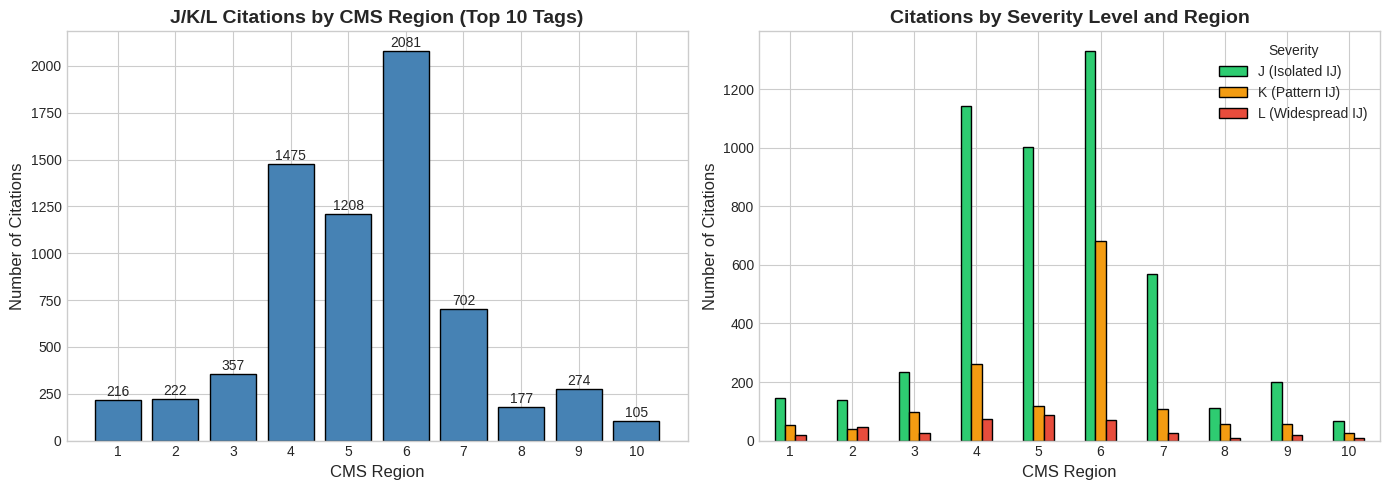


Citation counts by region:
cms_region   1    2    3     4     5     6    7    8    9    10
count       216  222  357  1475  1208  2081  702  177  274  105


In [ ]:
# Citations by CMS Region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Total citations by region
region_counts = df_analysis.groupby('cms_region').size().sort_index()
ax1 = axes[0]
bars = ax1.bar(region_counts.index, region_counts.values, color='steelblue', edgecolor='black')
ax1.set_xlabel('CMS Region', fontsize=12)
ax1.set_ylabel('Number of Citations', fontsize=12)
ax1.set_title('J/K/L Citations by CMS Region (Top 10 Tags)', fontsize=14, fontweight='bold')
ax1.set_xticks(range(1, 11))

# Add value labels
for bar, val in zip(bars, region_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
             str(val), ha='center', va='bottom', fontsize=10)

# Citations by severity within region
severity_by_region = df_analysis.groupby(['cms_region', 'scope_severity']).size().unstack(fill_value=0)
severity_by_region = severity_by_region[['J', 'K', 'L']]  # Ensure order

ax2 = axes[1]
severity_by_region.plot(kind='bar', ax=ax2, color=['#2ecc71', '#f39c12', '#e74c3c'], edgecolor='black')
ax2.set_xlabel('CMS Region', fontsize=12)
ax2.set_ylabel('Number of Citations', fontsize=12)
ax2.set_title('Citations by Severity Level and Region', fontsize=14, fontweight='bold')
ax2.legend(title='Severity', labels=['J (Isolated IJ)', 'K (Pattern IJ)', 'L (Widespread IJ)'])
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/01_citations_by_region.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nCitation counts by region:")
print(region_counts.to_frame('count').T)

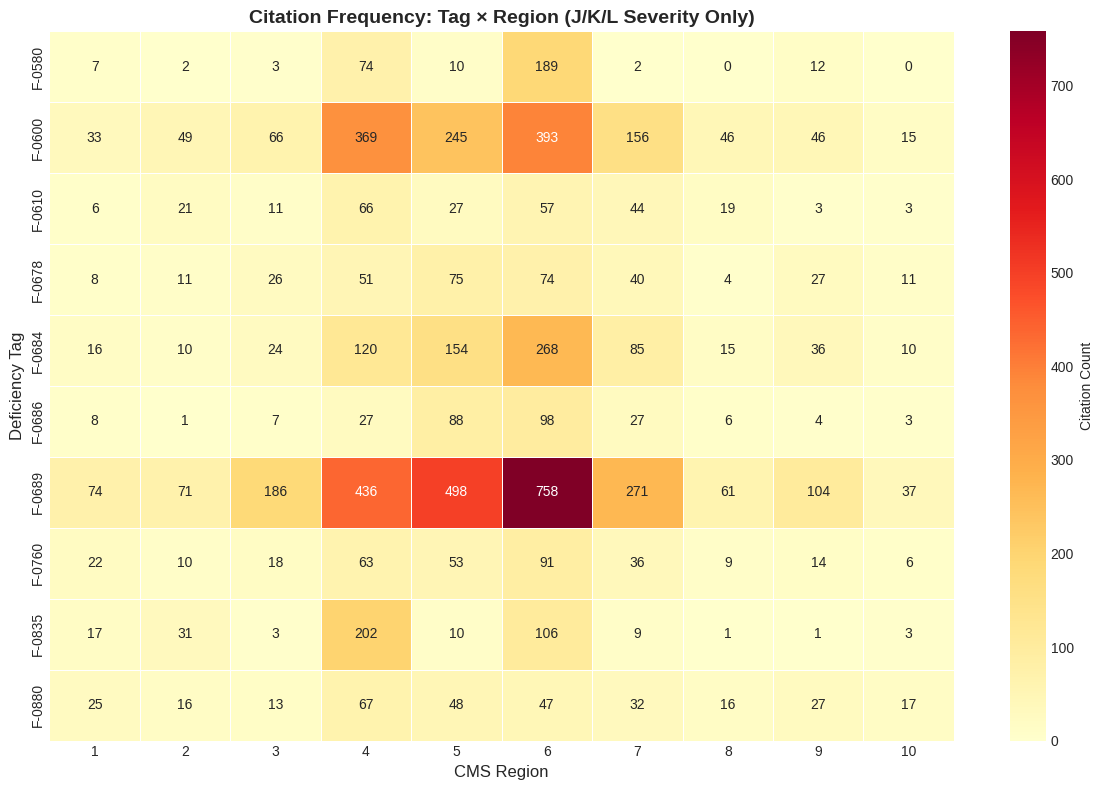

In [ ]:
# Heatmap - Tag × Region
pivot_tag_region = df_analysis.groupby(['deficiency_tag', 'cms_region']).size().unstack(fill_value=0)
pivot_tag_region.index = [f"F-0{t}" for t in pivot_tag_region.index]

fig, ax = plt.subplots(figsize=(12, 8))
sns.heatmap(pivot_tag_region, annot=True, fmt='d', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Citation Count'})
ax.set_xlabel('CMS Region', fontsize=12)
ax.set_ylabel('Deficiency Tag', fontsize=12)
ax.set_title('Citation Frequency: Tag × Region (J/K/L Severity Only)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/02_heatmap_tag_region.png', dpi=150, bbox_inches='tight')
plt.show()

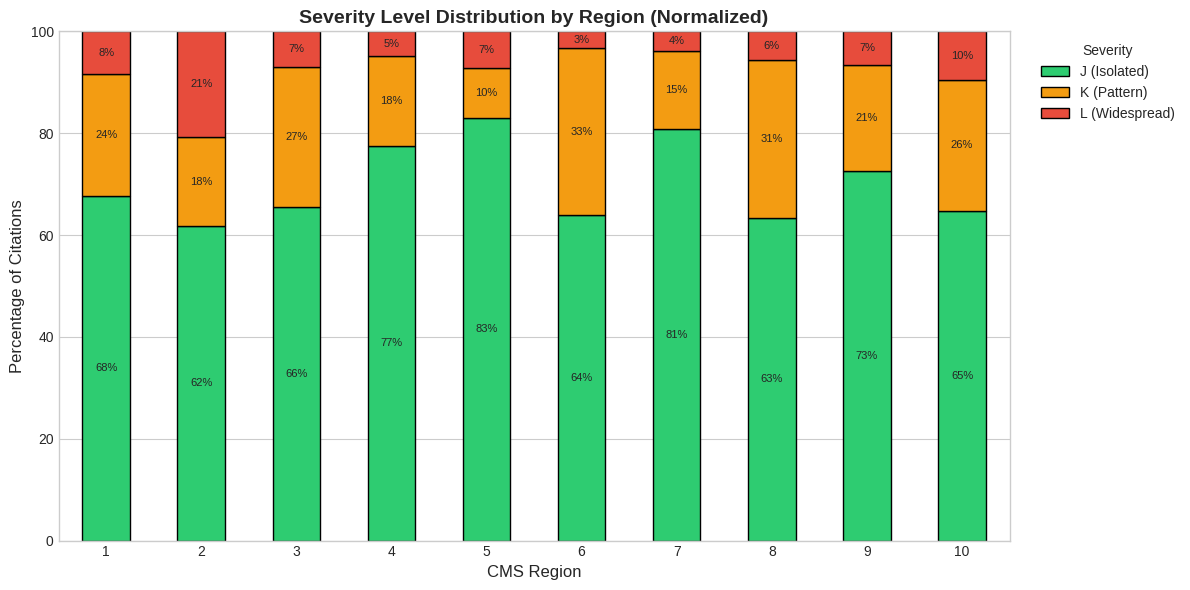


Severity distribution (%) by region:
scope_severity     J     K     L
cms_region                      
1               67.6  24.1   8.3
2               61.7  17.6  20.7
3               65.5  27.5   7.0
4               77.5  17.6   4.9
5               82.9   9.9   7.2
6               64.0  32.7   3.3
7               80.9  15.2   3.8
8               63.3  31.1   5.6
9               72.6  20.8   6.6
10              64.8  25.7   9.5


In [ ]:
# Severity distribution comparison across regions (normalized)
severity_pct = df_analysis.groupby(['cms_region', 'scope_severity']).size().unstack(fill_value=0)
severity_pct = severity_pct.div(severity_pct.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(12, 6))
severity_pct[['J', 'K', 'L']].plot(kind='bar', stacked=True, ax=ax,
                                    color=['#2ecc71', '#f39c12', '#e74c3c'],
                                    edgecolor='black')
ax.set_xlabel('CMS Region', fontsize=12)
ax.set_ylabel('Percentage of Citations', fontsize=12)
ax.set_title('Severity Level Distribution by Region (Normalized)', fontsize=14, fontweight='bold')
ax.legend(title='Severity', labels=['J (Isolated)', 'K (Pattern)', 'L (Widespread)'],
          bbox_to_anchor=(1.02, 1), loc='upper left')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.set_ylim(0, 100)

# Add percentage labels
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8)

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/03_severity_distribution_normalized.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSeverity distribution (%) by region:")
print(severity_pct.round(1))

## **3.2 Text Characteristics Analysis**

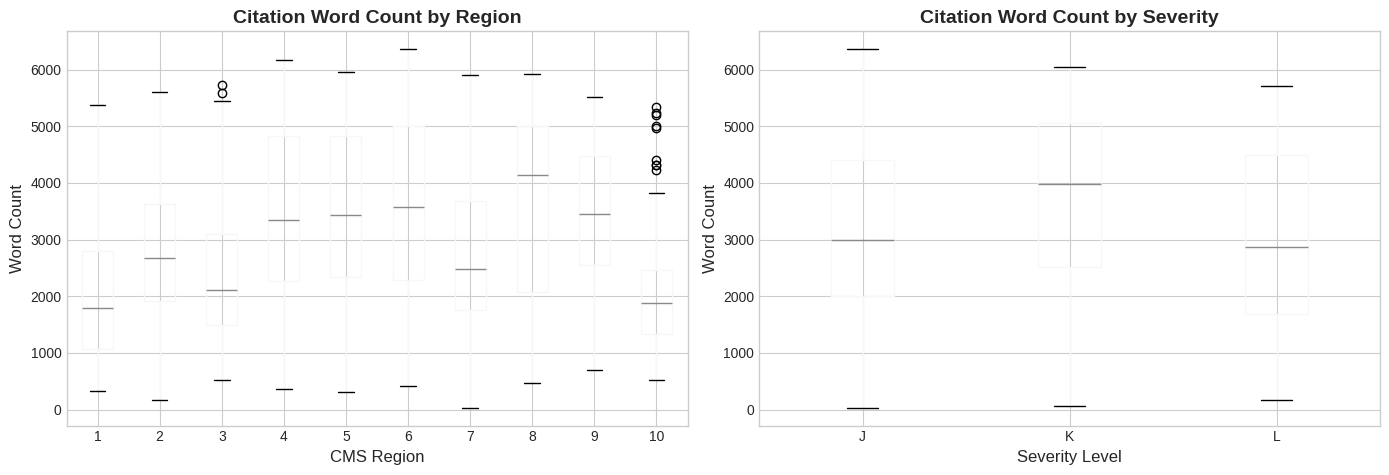

Word count statistics by region:
             count    mean     std    min     25%     50%     75%     max
cms_region                                                               
1            202.0  2096.0  1266.0  334.0  1078.0  1793.0  2802.0  5372.0
2            195.0  2835.0  1232.0  171.0  1922.0  2675.0  3628.0  5600.0
3            313.0  2418.0  1252.0  515.0  1486.0  2103.0  3106.0  5721.0
4           1334.0  3430.0  1412.0  373.0  2278.0  3352.0  4836.0  6172.0
5           1103.0  3477.0  1345.0  319.0  2347.0  3429.0  4828.0  5953.0
6           1860.0  3553.0  1480.0  412.0  2288.0  3576.0  5007.0  6360.0
7            655.0  2783.0  1310.0   35.0  1763.0  2490.0  3688.0  5909.0
8            160.0  3544.0  1645.0  471.0  2076.0  4147.0  5002.0  5928.0
9            249.0  3469.0  1124.0  700.0  2545.0  3446.0  4474.0  5522.0
10           101.0  2111.0  1118.0  522.0  1327.0  1890.0  2457.0  5343.0


In [ ]:
# Text length distribution by region
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Box plot of text length by region
ax1 = axes[0]
df_plot = df_analysis[df_analysis['text_available']].copy()
df_plot.boxplot(column='word_count', by='cms_region', ax=ax1)
ax1.set_xlabel('CMS Region', fontsize=12)
ax1.set_ylabel('Word Count', fontsize=12)
ax1.set_title('Citation Word Count by Region', fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove automatic title

# Box plot of text length by severity
ax2 = axes[1]
df_plot.boxplot(column='word_count', by='scope_severity', ax=ax2)
ax2.set_xlabel('Severity Level', fontsize=12)
ax2.set_ylabel('Word Count', fontsize=12)
ax2.set_title('Citation Word Count by Severity', fontsize=14, fontweight='bold')
plt.suptitle('')

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/04_text_length_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary statistics
print("Word count statistics by region:")
print(df_plot.groupby('cms_region')['word_count'].describe().round(0))

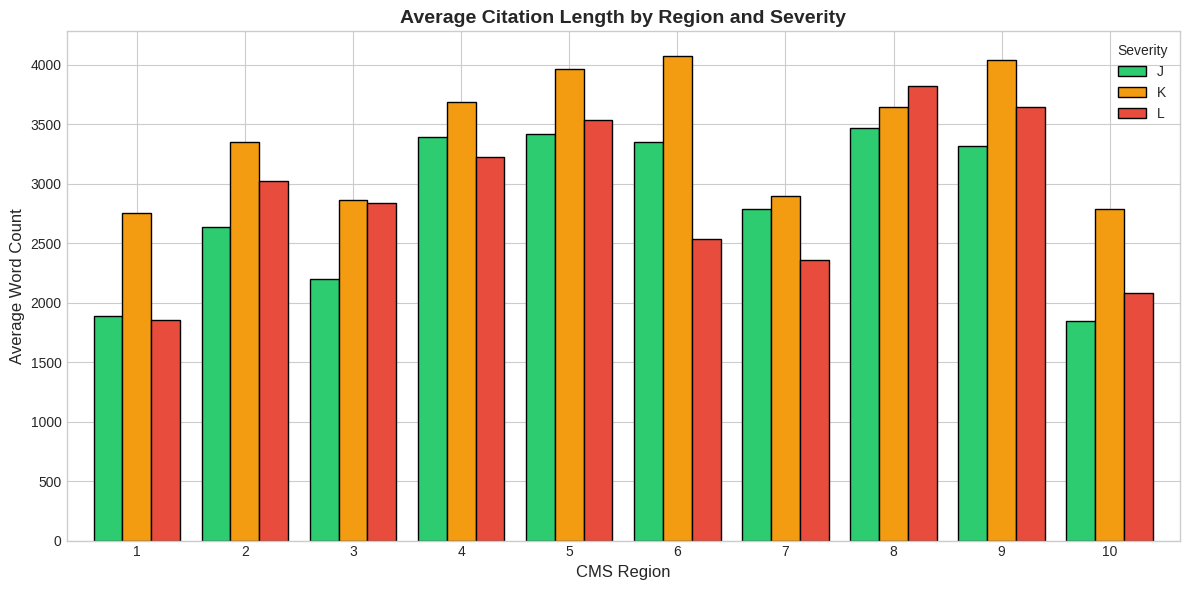

In [ ]:
# Text length by region AND severity (interaction)
fig, ax = plt.subplots(figsize=(12, 6))

# Create grouped data
text_stats = df_analysis[df_analysis['text_available']].groupby(
    ['cms_region', 'scope_severity'])['word_count'].mean().unstack()

text_stats[['J', 'K', 'L']].plot(kind='bar', ax=ax,
                                  color=['#2ecc71', '#f39c12', '#e74c3c'],
                                  edgecolor='black', width=0.8)
ax.set_xlabel('CMS Region', fontsize=12)
ax.set_ylabel('Average Word Count', fontsize=12)
ax.set_title('Average Citation Length by Region and Severity', fontsize=14, fontweight='bold')
ax.legend(title='Severity')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/05_text_length_region_severity.png', dpi=150, bbox_inches='tight')
plt.show()

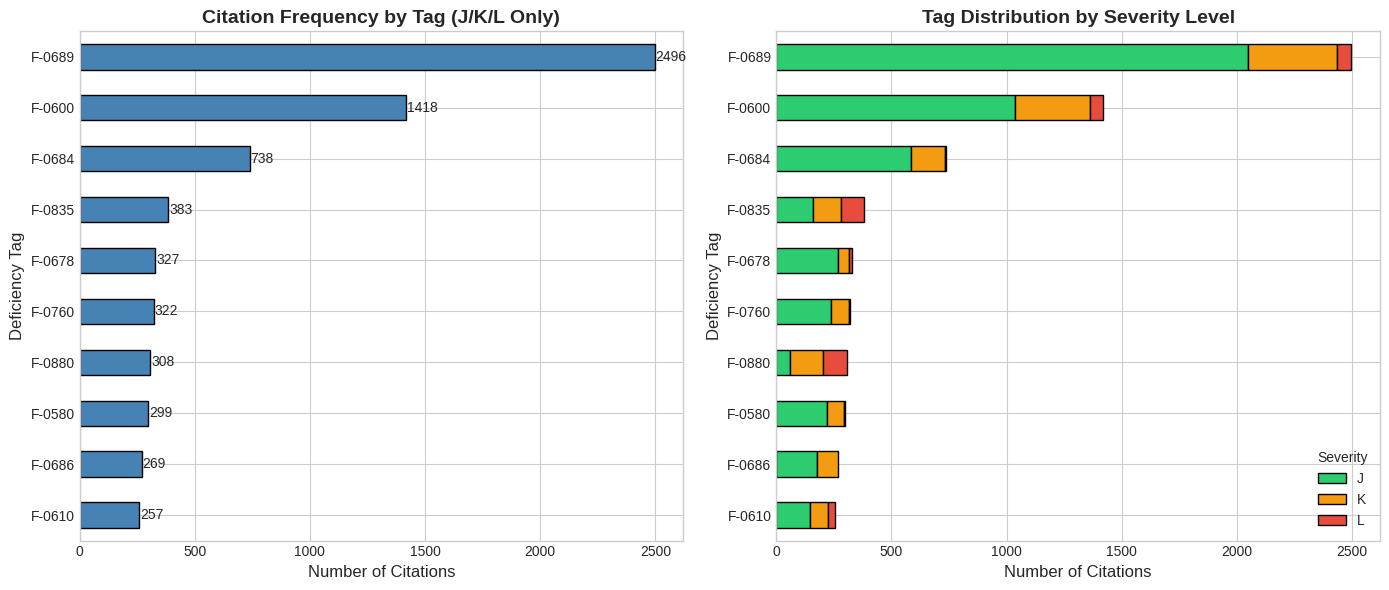

In [ ]:
# Top tags analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Overall tag frequency
ax1 = axes[0]
tag_counts = df_analysis['tag_label'].value_counts().sort_values(ascending=True)
tag_counts.plot(kind='barh', ax=ax1, color='steelblue', edgecolor='black')
ax1.set_xlabel('Number of Citations', fontsize=12)
ax1.set_ylabel('Deficiency Tag', fontsize=12)
ax1.set_title('Citation Frequency by Tag (J/K/L Only)', fontsize=14, fontweight='bold')

# Add value labels
for i, v in enumerate(tag_counts.values):
    ax1.text(v + 5, i, str(v), va='center', fontsize=10)

# Tag by severity
ax2 = axes[1]
tag_severity = df_analysis.groupby(['tag_label', 'scope_severity']).size().unstack(fill_value=0)
tag_severity = tag_severity.loc[tag_counts.index]  # Same order
tag_severity[['J', 'K', 'L']].plot(kind='barh', stacked=True, ax=ax2,
                                    color=['#2ecc71', '#f39c12', '#e74c3c'],
                                    edgecolor='black')
ax2.set_xlabel('Number of Citations', fontsize=12)
ax2.set_ylabel('Deficiency Tag', fontsize=12)
ax2.set_title('Tag Distribution by Severity Level', fontsize=14, fontweight='bold')
ax2.legend(title='Severity')

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/06_tag_frequency.png', dpi=150, bbox_inches='tight')
plt.show()

## **3.3 Temporal Analysis**

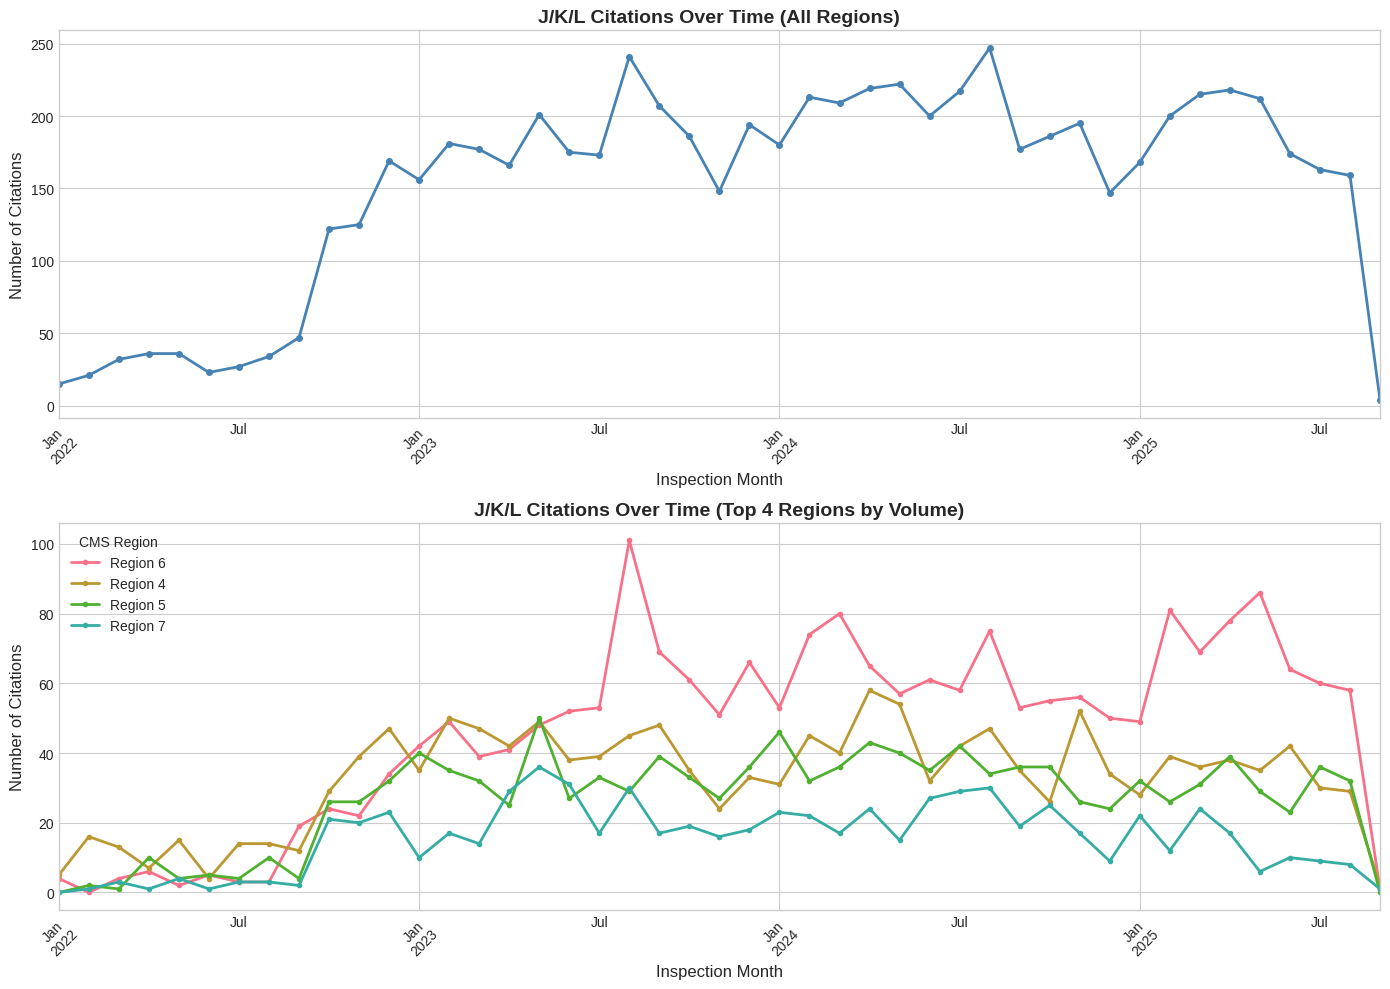

In [ ]:
# Citations over time
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Monthly trend overall
ax1 = axes[0]
monthly_counts = df_analysis.groupby('inspection_month').size()
monthly_counts.plot(ax=ax1, marker='o', linewidth=2, markersize=4, color='steelblue')
ax1.set_xlabel('Inspection Month', fontsize=12)
ax1.set_ylabel('Number of Citations', fontsize=12)
ax1.set_title('J/K/L Citations Over Time (All Regions)', fontsize=14, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)

# Monthly trend by region (selected regions for clarity)
ax2 = axes[1]
monthly_by_region = df_analysis.groupby(['inspection_month', 'cms_region']).size().unstack(fill_value=0)
# Plot top 4 regions by volume
top_regions = df_analysis['cms_region'].value_counts().head(4).index.tolist()
for region in top_regions:
    if region in monthly_by_region.columns:
        monthly_by_region[region].plot(ax=ax2, marker='o', linewidth=2, markersize=3, label=f'Region {region}')

ax2.set_xlabel('Inspection Month', fontsize=12)
ax2.set_ylabel('Number of Citations', fontsize=12)
ax2.set_title('J/K/L Citations Over Time (Top 4 Regions by Volume)', fontsize=14, fontweight='bold')
ax2.legend(title='CMS Region')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/07_temporal_trends.png', dpi=150, bbox_inches='tight')
plt.show()

## **3.4 State-Level Analysis**

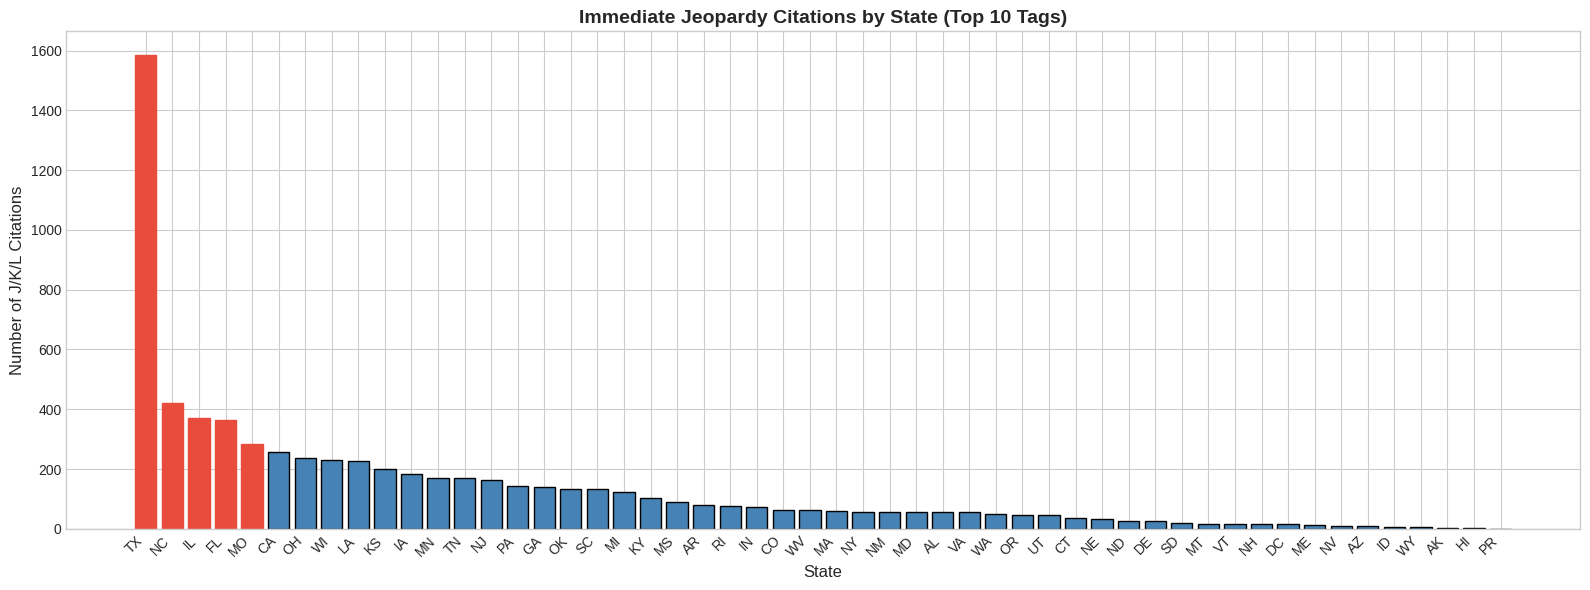


Top 10 states by J/K/L citations:
state
TX    1585
NC     421
IL     372
FL     363
MO     283
CA     256
OH     237
WI     232
LA     226
KS     201
Name: count, dtype: int64


In [ ]:
# Citations by state
fig, ax = plt.subplots(figsize=(16, 6))

state_counts = df_analysis['state'].value_counts().sort_values(ascending=False)
bars = ax.bar(range(len(state_counts)), state_counts.values, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(state_counts)))
ax.set_xticklabels(state_counts.index, rotation=45, ha='right')
ax.set_xlabel('State', fontsize=12)
ax.set_ylabel('Number of J/K/L Citations', fontsize=12)
ax.set_title('Immediate Jeopardy Citations by State (Top 10 Tags)', fontsize=14, fontweight='bold')

# Highlight top 5 states
for i in range(min(5, len(bars))):
    bars[i].set_color('#e74c3c')

plt.tight_layout()
plt.savefig('/content/gdrive/My Drive/AHCA Project/figures/08_citations_by_state.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTop 10 states by J/K/L citations:")
print(state_counts.head(10))

# **4. Summary Statistics for Analysis**

In [ ]:
# Generate summary statistics table
summary_stats = []

for region in sorted(df_analysis['cms_region'].unique()):
    region_data = df_analysis[df_analysis['cms_region'] == region]
    text_data = region_data[region_data['text_available']]

    stats = {
        'CMS Region': region,
        'Total Citations': len(region_data),
        'J Count': len(region_data[region_data['scope_severity'] == 'J']),
        'K Count': len(region_data[region_data['scope_severity'] == 'K']),
        'L Count': len(region_data[region_data['scope_severity'] == 'L']),
        'Unique Facilities': region_data['facility_id'].nunique(),
        'States': ', '.join(sorted(region_data['state'].unique())),
        'Avg Word Count': text_data['word_count'].mean() if len(text_data) > 0 else 0,
        'Median Word Count': text_data['word_count'].median() if len(text_data) > 0 else 0,
        'Text Available %': (region_data['text_available'].sum() / len(region_data) * 100) if len(region_data) > 0 else 0
    }
    summary_stats.append(stats)

summary_df = pd.DataFrame(summary_stats)
summary_df = summary_df.round(1)

print("=== REGIONAL SUMMARY STATISTICS ===\n")
print(summary_df.to_string(index=False))

# Save summary
summary_df.to_csv('/content/gdrive/My Drive/AHCA Project/filtered_data_sets/regional_summary_statistics.csv', index=False)
print("\nSummary saved to: regional_summary_statistics.csv")

=== REGIONAL SUMMARY STATISTICS ===

 CMS Region  Total Citations  J Count  K Count  L Count  Unique Facilities                         States  Avg Word Count  Median Word Count  Text Available %
          1              216      146       52       18                135         CT, MA, ME, NH, RI, VT          2095.5             1793.0              93.5
          2              222      137       39       46                142                     NJ, NY, PR          2835.2             2675.0              87.8
          3              357      234       98       25                256         DC, DE, MD, PA, VA, WV          2418.2             2103.0              87.7
          4             1475     1143      260       72                689 AL, FL, GA, KY, MS, NC, SC, TN          3429.6             3352.0              90.4
          5             1208     1002      119       87                775         IL, IN, MI, MN, OH, WI          3476.7             3429.0              91.3
         

In [ ]:
# Tag-level summary
tag_summary = []

for tag in TARGET_TAGS:
    tag_data = df_analysis[df_analysis['deficiency_tag'] == tag]
    text_data = tag_data[tag_data['text_available']]

    stats = {
        'Tag': f'F-0{tag}',
        'Description': TAG_DESCRIPTIONS.get(tag, '').split(': ')[-1] if tag in TAG_DESCRIPTIONS else '',
        'Total Citations': len(tag_data),
        'Regions with Citations': tag_data['cms_region'].nunique(),
        'J Count': len(tag_data[tag_data['scope_severity'] == 'J']),
        'K Count': len(tag_data[tag_data['scope_severity'] == 'K']),
        'L Count': len(tag_data[tag_data['scope_severity'] == 'L']),
        'Avg Word Count': text_data['word_count'].mean() if len(text_data) > 0 else 0,
    }
    tag_summary.append(stats)

tag_summary_df = pd.DataFrame(tag_summary)
tag_summary_df = tag_summary_df.round(1)
tag_summary_df = tag_summary_df.sort_values('Total Citations', ascending=False)

print("=== TAG-LEVEL SUMMARY ===\n")
print(tag_summary_df.to_string(index=False))

# Save
tag_summary_df.to_csv('/content/gdrive/My Drive/AHCA Project/filtered_data_sets/tag_summary_statistics.csv', index=False)

=== TAG-LEVEL SUMMARY ===

   Tag                                        Description  Total Citations  Regions with Citations  J Count  K Count  L Count  Avg Word Count
F-0689       Free of Accident Hazards/Supervision/Devices             2496                      10     2049      383       64          3162.0
F-0600                        Free from Abuse and Neglect             1418                      10     1037      327       54          3606.1
F-0684                                    Quality of Care              738                      10      587      145        6          3640.4
F-0835                                     Administration              383                      10      160      121      102          2295.1
F-0678               Cardio-Pulmonary Resuscitation (CPR)              327                      10      266       49       12          2721.1
F-0760     Medication Regimen Free from Unnecessary Drugs              322                      10      238       79     

# **LLM ANALYSIS STARTS HERE**

In [ ]:
!pip install pdfplumber

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.9/67.9 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 113.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 98.0 MB/s eta 0:00:00


In [ ]:


import pdfplumber

import re

PDF_PATH = Path('/content/gdrive/My Drive/AHCA Project/SOM-Appendix-PP.pdf')

print("="*80)
print("FINAL EXTRACTION: Regulatory Text by CFR Section")
print("="*80 + "\n")

FINAL EXTRACTION: Regulatory Text by CFR Section




**Diagnosis**

In [ ]:
print("="*80)
print("DIAGNOSTIC: Finding Actual Section Locations")
print("="*80 + "\n")

# Extract text from all pages
with pdfplumber.open(PDF_PATH) as pdf:
    num_pages = len(pdf.pages)
    print(f"Total pages: {num_pages}\n")

    # Build full text with page tracking
    full_text = ""
    page_contents = {}  # Store each page separately

    for page_num in range(num_pages):
        page = pdf.pages[page_num]
        text = page.extract_text()
        page_contents[page_num + 1] = text  # Store by page number (1-indexed)
        full_text += f"\n[PAGE {page_num + 1}]\n" + text

DIAGNOSTIC: Finding Actual Section Locations

Total pages: 926



In [ ]:
# Search for all occurrences of each CFR section
CFR_SECTIONS = ['§483.10', '§483.12', '§483.25', '§483.35', '§483.45', '§483.70', '§483.80']

print("="*80)
print("ALL OCCURRENCES OF CFR SECTIONS IN PDF")
print("="*80 + "\n")

section_locations = {}

for cfr in CFR_SECTIONS:
    # Find all occurrences
    matches = [(m.start(), m.end()) for m in re.finditer(re.escape(cfr), full_text)]

    print(f"{cfr}: Found {len(matches)} occurrence(s)")

    section_locations[cfr] = []

    for match_num, (start, end) in enumerate(matches):
        # Find which page this is on
        page_marker_pattern = r'\[PAGE (\d+)\]'
        page_matches = list(re.finditer(page_marker_pattern, full_text[:start]))

        if page_matches:
            page_num = int(page_matches[-1].group(1))
        else:
            page_num = 1

        # Get context around the match (500 chars before and after)
        context_start = max(0, start - 500)
        context_end = min(len(full_text), end + 500)
        context = full_text[context_start:context_end]

        section_locations[cfr].append({
            'occurrence': match_num + 1,
            'page': page_num,
            'position': start,
            'context': context[:200] + "..." if len(context) > 200 else context
        })

        print(f"  Occurrence {match_num + 1}: Page {page_num}")

ALL OCCURRENCES OF CFR SECTIONS IN PDF

§483.10: Found 341 occurrence(s)
  Occurrence 1: Page 1
  Occurrence 2: Page 6
  Occurrence 3: Page 6
  Occurrence 4: Page 6
  Occurrence 5: Page 6
  Occurrence 6: Page 6
  Occurrence 7: Page 6
  Occurrence 8: Page 6
  Occurrence 9: Page 7
  Occurrence 10: Page 9
  Occurrence 11: Page 9
  Occurrence 12: Page 10
  Occurrence 13: Page 10
  Occurrence 14: Page 10
  Occurrence 15: Page 11
  Occurrence 16: Page 11
  Occurrence 17: Page 11
  Occurrence 18: Page 11
  Occurrence 19: Page 11
  Occurrence 20: Page 11
  Occurrence 21: Page 12
  Occurrence 22: Page 13
  Occurrence 23: Page 14
  Occurrence 24: Page 14
  Occurrence 25: Page 14
  Occurrence 26: Page 15
  Occurrence 27: Page 15
  Occurrence 28: Page 15
  Occurrence 29: Page 15
  Occurrence 30: Page 15
  Occurrence 31: Page 16
  Occurrence 32: Page 16
  Occurrence 33: Page 16
  Occurrence 34: Page 16
  Occurrence 35: Page 16
  Occurrence 36: Page 17
  Occurrence 37: Page 17
  Occurrence 38: Page 

In [ ]:
# Show first substantial occurrence of each section
print("\n" + "="*80)
print("FIRST SUBSTANTIAL OCCURRENCE OF EACH SECTION")
print("="*80 + "\n")

for cfr in CFR_SECTIONS:
    if cfr in section_locations and len(section_locations[cfr]) > 0:
        first_occurrence = section_locations[cfr][0]
        page = first_occurrence['page']

        # Get the page content
        if page in page_contents:
            page_text = page_contents[page]
            # Find the CFR in this page and show what comes after it
            idx = page_text.find(cfr)
            if idx != -1:
                following_text = page_text[idx:min(idx + 500, len(page_text))]
                print(f"{cfr} (Page {page}):")
                print(f"  Following text: {following_text[:300]}...\n")


FIRST SUBSTANTIAL OCCURRENCE OF EACH SECTION

§483.10 (Page 1):
  Following text: §483.10 Resident Rights
§483.12 Freedom from Abuse, Neglect, and Exploitation
§483.15 Admission Transfer and Discharge Rights
§483.20 Resident Assessment
§483.21 Comprehensive Person-Centered Care Plans
§483.24 Quality of Life
§483.25 Quality of Care
§483.30 Physician Services
§483.35 Nursing Servic...

§483.12 (Page 1):
  Following text: §483.12 Freedom from Abuse, Neglect, and Exploitation
§483.15 Admission Transfer and Discharge Rights
§483.20 Resident Assessment
§483.21 Comprehensive Person-Centered Care Plans
§483.24 Quality of Life
§483.25 Quality of Care
§483.30 Physician Services
§483.35 Nursing Services
§483.40 Behavioral he...

§483.25 (Page 1):
  Following text: §483.25 Quality of Care
§483.30 Physician Services
§483.35 Nursing Services
§483.40 Behavioral health services
§483.45 Pharmacy Services
§483.50 Laboratory Radiology and Other Diagnostic Services
§483.55 Dental Services
§483.60 Food an

In [ ]:
# List all unique pages where CFR sections appear
print("="*80)
print("SUMMARY: Pages Containing Each CFR Section")
print("="*80 + "\n")

for cfr in CFR_SECTIONS:
    if cfr in section_locations:
        pages = [loc['page'] for loc in section_locations[cfr]]
        unique_pages = sorted(set(pages))
        print(f"{cfr}: Pages {unique_pages}")

print("\n" + "="*80)
print("NEXT STEPS:")
print("="*80)
print("""
Based on the above, we need to:
1. Determine the correct extraction method (pages vs. boundaries)
2. Extract content from the right pages
3. Save the complete regulatory text for each section
""")

SUMMARY: Pages Containing Each CFR Section

§483.10: Pages [1, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 55, 56, 57, 58, 59, 61, 62, 63, 64, 65, 67, 68, 69, 70, 71, 79, 80, 85, 90, 104, 115, 116, 117, 127, 130, 135, 137, 139, 179, 189, 190, 192, 194, 195, 204, 205, 206, 236, 249, 251, 254, 255, 259, 263, 264, 267, 269, 273, 274, 287, 288, 289, 295, 296, 301, 331, 364, 379, 429, 474, 493, 501, 586, 615, 616, 619, 620, 641, 650, 653, 659, 671, 672, 681, 707, 708, 711, 720, 747, 751, 755, 768, 842, 873, 896, 897, 907, 909]
§483.12: Pages [1, 9, 10, 68, 69, 70, 71, 72, 79, 82, 89, 90, 97, 98, 104, 105, 107, 109, 114, 115, 117, 120, 125, 130, 135, 137, 148, 151, 152, 153, 162, 163, 165, 168, 169, 170, 171, 184, 189, 252, 256, 267, 274, 276, 287, 288, 306, 357, 371, 509, 512, 551, 556, 585, 586, 602, 616, 707, 774, 912, 913]
§483.25: Pages [1, 22, 27, 32, 68,

In [ ]:
# ============================================================================
# FINAL EXTRACTION: Use First Occurrence After Page 1
# ============================================================================
# Strategy: For each CFR section, use the FIRST occurrence after page 1
# as the start of the actual regulatory content
# ============================================================================

# STEP 2: Define CFR sections and their first occurrence (from diagnostic)
CFR_SECTIONS = {
    '§483.10': 'Resident Rights',
    '§483.12': 'Freedom from Abuse, Neglect, and Exploitation',
    '§483.25': 'Quality of Care',
    '§483.35': 'Nursing Services',
    '§483.45': 'Pharmacy Services',
    '§483.70': 'Administration',
    '§483.80': 'Infection Control'
}

# First occurrence of each section (skipping page 1)
FIRST_OCCURRENCE_PAGES = {
    '§483.10': 6,      # First on page 6 (skipping page 1 index)
    '§483.12': 9,      # First on page 9
    '§483.25': 22,     # First on page 22
    '§483.35': 28,     # First on page 28
    '§483.45': 18,     # First on page 18
    '§483.70': 62,     # First on page 62
    '§483.80': 68      # First on page 68
}

TAG_TO_CFR = {
    '580': ('§483.10', 'Notify of Changes'),
    '600': ('§483.12', 'Free from Abuse and Neglect'),
    '610': ('§483.12', 'Investigate/Prevent/Correct Abuse'),
    '678': ('§483.35', 'Nursing Services - CPR'),
    '684': ('§483.25', 'Quality of Care'),
    '686': ('§483.25', 'Quality of Care - Pressure Ulcers'),
    '689': ('§483.25', 'Quality of Care - Safety Hazards'),
    '760': ('§483.45', 'Pharmacy Services - Medication'),
    '835': ('§483.70', 'Administration'),
    '880': ('§483.80', 'Infection Prevention & Control')
}

In [ ]:
# STEP 3: Extract content from first occurrence page onwards
print("="*80)
print("Step 2: Extracting regulatory content from first occurrence pages")
print("="*80 + "\n")

extracted_sections = {}

cfr_list = sorted(FIRST_OCCURRENCE_PAGES.items(), key=lambda x: x[1])  # Sort by page number

for idx, (cfr_code, start_page) in enumerate(cfr_list):
    cfr_title = CFR_SECTIONS[cfr_code]

    # Determine where this section ends
    if idx + 1 < len(cfr_list):
        # End at the next section's start page
        next_cfr, next_page = cfr_list[idx + 1]
        end_page = next_page - 1
    else:
        # Last section: go to end of document
        end_page = num_pages

    # Extract text from start_page to end_page
    section_text = ""
    for page_num in range(start_page, end_page + 1):
        if page_num in page_contents and page_contents[page_num]:
            section_text += page_contents[page_num] + " "

    # Clean up
    section_text = section_text.strip()
    section_text = re.sub(r'\s+', ' ', section_text)

    extracted_sections[cfr_code] = section_text

    print(f"✅ {cfr_code} - {cfr_title}")
    print(f"   Pages: {start_page} to {end_page}")
    print(f"   Length: {len(section_text):,} characters")
    print(f"   Preview: {section_text[:150]}...\n")

Step 2: Extracting regulatory content from first occurrence pages

✅ §483.10 - Resident Rights
   Pages: 6 to 8
   Length: 7,106 characters
   Preview: Representative of direct care employees. A representative of direct care employees is an employee of the facility, or a third party authorized by dire...

✅ §483.12 - Freedom from Abuse, Neglect, and Exploitation
   Pages: 9 to 17
   Length: 25,787 characters
   Preview: conflict with CMS requirements. If the facility accepts responsibility for enforcing restrictive law enforcement terms applied to a resident that are ...

✅ §483.45 - Pharmacy Services
   Pages: 18 to 21
   Length: 10,876 characters
   Preview: §483.10(c)(7) The right to self-administer medications if the interdisciplinary team, as defined by §483.21(b)(2)(ii), has determined that this practi...

✅ §483.25 - Quality of Care
   Pages: 22 to 27
   Length: 15,486 characters
   Preview: provision of supervision to prevent accidental overdose, investigate potential non-compl

In [ ]:
# STEP 4: Map to deficiency tags
print("="*80)
print("Step 3: Creating regulatory baseline by tag")
print("="*80 + "\n")

regulatory_baseline = []

for tag_num, (cfr_code, tag_desc) in TAG_TO_CFR.items():
    tag_code = f'F-0{tag_num}'
    cfr_title = CFR_SECTIONS.get(cfr_code, 'Unknown')
    section_text = extracted_sections.get(cfr_code, "[NOT FOUND]")

    regulatory_baseline.append({
        'Tag': tag_code,
        'Tag_Description': tag_desc,
        'CFR_Section': cfr_code,
        'CFR_Title': cfr_title,
        'Regulatory_Text': section_text,
        'Text_Length': len(section_text)
    })

regulatory_df = pd.DataFrame(regulatory_baseline)

print("Summary Table:")
print(regulatory_df[['Tag', 'CFR_Section', 'Text_Length']].to_string(index=False))

Step 3: Creating regulatory baseline by tag

Summary Table:
   Tag CFR_Section  Text_Length
F-0580     §483.10         7106
F-0600     §483.12        25787
F-0610     §483.12        25787
F-0678     §483.35        91838
F-0684     §483.25        15486
F-0686     §483.25        15486
F-0689     §483.25        15486
F-0760     §483.45        10876
F-0835     §483.70        17077
F-0880     §483.80       467719


In [ ]:
# STEP 5: Save to CSV
print("\n" + "="*80)
print("Step 4: Saving to CSV")
print("="*80 + "\n")

output_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')
output_dir.mkdir(parents=True, exist_ok=True)

output_path = output_dir / 'appendix_pp_regulatory_baseline.csv'
regulatory_df.to_csv(output_path, index=False)

print(f"✅ Saved to: {output_path}")
print(f"✅ File size: {output_path.stat().st_size:,} bytes")
print(f"✅ Rows: {len(regulatory_df)}")


Step 4: Saving to CSV

✅ Saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/appendix_pp_regulatory_baseline.csv
✅ File size: 699,959 bytes
✅ Rows: 10


In [ ]:
# STEP 6: Detailed preview
print("\n" + "="*80)
print("Step 5: Preview of Extracted Regulatory Text")
print("="*80 + "\n")

for tag_code in ['F-0600', 'F-0689', 'F-0835']:
    row = regulatory_df[regulatory_df['Tag'] == tag_code]

    if len(row) > 0:
        text_length = row['Text_Length'].values[0]
        text = row['Regulatory_Text'].values[0]
        cfr = row['CFR_Section'].values[0]

        print(f"{tag_code} ({cfr})")
        print(f"Length: {text_length:,} characters\n")
        print("First 1000 characters:")
        print("-" * 80)
        print(text[:1000])
        print("\n" + "-" * 80 + "\n")


Step 5: Preview of Extracted Regulatory Text

F-0600 (§483.12)
Length: 25,787 characters

First 1000 characters:
--------------------------------------------------------------------------------
conflict with CMS requirements. If the facility accepts responsibility for enforcing restrictive law enforcement terms applied to a resident that are contrary to the Requirements for LTC Facilities, the facility would not be in compliance with federal long term care requirements. In addition, law enforcement jurisdictions may not be integrated with the operations of the facility. While all portions of 42 CFR Part 483, Subpart B, apply to justice involved individuals, other areas where there may be concerns specific to this population are found at §483.12, F600, Abuse, Neglect, and Exploitation and §483.15(c), F622, Transfer and discharge. In such a case, surveyors should cite under the specific tag associated with the concern identified. For example, if there is a concern about a facility restr

In [ ]:
# STEP 7: Final summary
print("="*80)
print("EXTRACTION COMPLETE")
print("="*80)
print(f"\n✅ Total tags: {len(regulatory_df)}")
print(f"✅ Total regulatory text: {regulatory_df['Text_Length'].sum():,} characters")
print(f"✅ Average per tag: {regulatory_df['Text_Length'].mean():,.0f} characters")
print(f"\nThe regulatory baseline CSV is ready for:")
print("  • RQ2: Regulatory Alignment Analysis")
print("  • Measuring semantic distance between citations and regulations")

EXTRACTION COMPLETE

✅ Total tags: 10
✅ Total regulatory text: 692,648 characters
✅ Average per tag: 69,265 characters

The regulatory baseline CSV is ready for:
  • RQ2: Regulatory Alignment Analysis
  • Measuring semantic distance between citations and regulations


============================================================================
### WEEK 3-4: CONSISTENCY ANALYSIS & REGULATORY ALIGNMENT
============================================================================
### Load citation data and regulatory baseline, prepare for embedding generation
============================================================================

In [ ]:
print("="*80)
print("CELL 1: PREPARE DATA FOR EMBEDDING GENERATION")
print("="*80 + "\n")

CELL 1: PREPARE DATA FOR EMBEDDING GENERATION



In [ ]:
# %%
# STEP 1: Load Citation Data
print("Step 1: Loading citation data...\n")

citation_path = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets/analysis_dataset_jkl_top10tags.csv')

try:
    df_citations = pd.read_csv(citation_path)
    print(f"✅ Loaded citations: {len(df_citations):,} rows")
    print(f"✅ Columns: {list(df_citations.columns)}")
    print(f"\nCitation data shape: {df_citations.shape}")
    print(f"Memory usage: {df_citations.memory_usage(deep=True).sum() / 1024**2:.1f} MB\n")
except FileNotFoundError:
    print(f"❌ File not found: {citation_path}")
    print("Make sure you have run the EDA notebook and saved the filtered dataset")
    raise

Step 1: Loading citation data...

✅ Loaded citations: 6,817 rows
✅ Columns: ['facility_name', 'facility_id', 'address', 'city', 'state', 'zip', 'inspection_date', 'deficiency_tag', 'scope_severity', 'complaint', 'standard', 'infctrl', 'IDR', 'IIDR', 'eventid', 'inspection_text', 'cms_region', 'source_file', 'inspection_year', 'inspection_month', 'text_length', 'word_count', 'text_available', 'tag_label']

Citation data shape: (6817, 24)
Memory usage: 138.5 MB



In [ ]:
# %%
# STEP 2: Verify Citation Data Structure
print("Step 2: Verifying citation data structure...\n")

required_columns = ['facility_id', 'inspection_text', 'deficiency_tag', 'cms_region', 'scope_severity']
missing_columns = [col for col in required_columns if col not in df_citations.columns]

if missing_columns:
    print(f"⚠️ Missing columns: {missing_columns}")
    print(f"Available columns: {list(df_citations.columns)}")
else:
    print(f"✅ All required columns present: {required_columns}\n")

# Check for missing text
text_missing = df_citations['inspection_text'].isna().sum()
print(f"Missing citation texts: {text_missing} ({100*text_missing/len(df_citations):.1f}%)")

# Sample data
print(f"\nSample citation data:")
print(df_citations[['facility_id', 'deficiency_tag', 'cms_region', 'scope_severity']].head(3))

Step 2: Verifying citation data structure...

✅ All required columns present: ['facility_id', 'inspection_text', 'deficiency_tag', 'cms_region', 'scope_severity']

Missing citation texts: 0 (0.0%)

Sample citation data:
  facility_id  deficiency_tag  cms_region scope_severity
0     75011.0             600           1              J
1     75017.0             760           1              J
2     75063.0             600           1              J


In [ ]:
# %%
# STEP 3: Load Regulatory Baseline
print("\n" + "="*80)
print("Step 3: Loading regulatory baseline...\n")

regulatory_path = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets/appendix_pp_regulatory_baseline.csv')

try:
    df_regulatory = pd.read_csv(regulatory_path)
    print(f"✅ Loaded regulatory baseline: {len(df_regulatory)} rows (one per tag)")
    print(f"✅ Columns: {list(df_regulatory.columns)}\n")
except FileNotFoundError:
    print(f"❌ File not found: {regulatory_path}")
    print("Make sure you have run the Appendix PP extraction notebook first")
    raise

# Verify regulatory data
print("Regulatory baseline data:")
print(df_regulatory[['Tag', 'CFR_Section', 'Text_Length']].to_string(index=False))


Step 3: Loading regulatory baseline...

✅ Loaded regulatory baseline: 10 rows (one per tag)
✅ Columns: ['Tag', 'Tag_Description', 'CFR_Section', 'CFR_Title', 'Regulatory_Text', 'Text_Length']

Regulatory baseline data:
   Tag CFR_Section  Text_Length
F-0580     §483.10         7106
F-0600     §483.12        25787
F-0610     §483.12        25787
F-0678     §483.35        91838
F-0684     §483.25        15486
F-0686     §483.25        15486
F-0689     §483.25        15486
F-0760     §483.45        10876
F-0835     §483.70        17077
F-0880     §483.80       467719


In [ ]:
# %%
# STEP 4: Clean and Prepare Text
print("\n" + "="*80)
print("Step 4: Cleaning and preparing text data...\n")

# Function to clean text
def clean_text(text):
    """Clean citation and regulatory text for embedding"""
    if pd.isna(text):
        return ""

    # Convert to string
    text = str(text)

    # Remove extra whitespace
    text = ' '.join(text.split())

    # Remove special characters but keep punctuation
    text = text.replace('\n', ' ').replace('\r', ' ').replace('\t', ' ')

    # Strip whitespace
    text = text.strip()

    return text

# Clean citation texts
print("Cleaning citation texts...")
df_citations['text_clean'] = df_citations['inspection_text'].apply(clean_text)

# Check for empty texts after cleaning
empty_texts = (df_citations['text_clean'].str.len() == 0).sum()
print(f"Empty texts after cleaning: {empty_texts}")

# Remove empty texts
df_citations = df_citations[df_citations['text_clean'].str.len() > 0]
print(f"Citations remaining: {len(df_citations):,}\n")

# Clean regulatory texts
print("Cleaning regulatory texts...")
df_regulatory['text_clean'] = df_regulatory['Regulatory_Text'].apply(clean_text)

print(f"✅ All regulatory texts cleaned")
print(f"✅ Sample cleaned regulatory text (first 300 chars):")
print(f"   {df_regulatory['text_clean'].iloc[0][:300]}...\n")


Step 4: Cleaning and preparing text data...

Cleaning citation texts...
Empty texts after cleaning: 0
Citations remaining: 6,817

Cleaning regulatory texts...
✅ All regulatory texts cleaned
✅ Sample cleaned regulatory text (first 300 chars):
   Representative of direct care employees. A representative of direct care employees is an employee of the facility, or a third party authorized by direct care employees at the facility to provide expertise and input on behalf of the employees for the purposes of informing a facility assessment. Sexua...



In [ ]:
# %%
# STEP 5: Create Citation Metadata
print("="*80)
print("Step 5: Creating citation metadata and IDs...\n")

# Create unique citation ID for tracking
df_citations['citation_id'] = (
    df_citations['facility_id'].astype(str) + '_' +
    df_citations['deficiency_tag'].astype(str) + '_' +
    df_citations['cms_region'].astype(str) + '_' +
    df_citations.groupby(['facility_id', 'deficiency_tag', 'cms_region']).cumcount().astype(str)
)

# Rename columns for consistency
df_citations = df_citations.rename(columns={
    'deficiency_tag': 'tag',
    'cms_region': 'region',
    'scope_severity': 'severity'
})

# Keep only needed columns
df_citations_processed = df_citations[[
    'citation_id',
    'facility_id',
    'tag',
    'region',
    'severity',
    'text_clean',
    'inspection_text'  # Keep original for reference
]].copy()

print(f"Citation metadata created:")
print(f"✅ Total citations: {len(df_citations_processed):,}")
print(f"✅ Unique facilities: {df_citations_processed['facility_id'].nunique()}")
print(f"✅ Tags represented: {sorted(df_citations_processed['tag'].unique())}")
print(f"✅ Regions: {sorted(df_citations_processed['region'].unique())}\n")

# Summary by region
print("Citations by region:")
region_summary = df_citations_processed.groupby('region').agg({
    'citation_id': 'count',
    'facility_id': 'nunique'
}).rename(columns={'citation_id': 'citations', 'facility_id': 'facilities'})
print(region_summary)

# Summary by tag
print("\nCitations by tag:")
tag_summary = df_citations_processed.groupby('tag').agg({
    'citation_id': 'count',
    'region': 'nunique'
}).rename(columns={'citation_id': 'citations', 'region': 'regions'})
print(tag_summary.sort_values('citations', ascending=False))

Step 5: Creating citation metadata and IDs...

Citation metadata created:
✅ Total citations: 6,817
✅ Unique facilities: 3800
✅ Tags represented: [np.int64(580), np.int64(600), np.int64(610), np.int64(678), np.int64(684), np.int64(686), np.int64(689), np.int64(760), np.int64(835), np.int64(880)]
✅ Regions: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]

Citations by region:
        citations  facilities
region                       
1             216         135
2             222         142
3             357         256
4            1475         689
5            1208         775
6            2081         977
7             702         423
8             177         123
9             274         193
10            105          87

Citations by tag:
     citations  regions
tag                    
689       2496       10
600       1418       10
684        738       10
835        383       10
678        327  

In [ ]:
# %%
# STEP 6: Create Regulatory Metadata
print("\n" + "="*80)
print("Step 6: Creating regulatory metadata...\n")

# Extract tag number from tag code (F-0600 -> 600)
df_regulatory['tag'] = df_regulatory['Tag'].str.replace('F-0', '').astype(int)

df_regulatory_processed = df_regulatory[[
    'tag',
    'Tag',
    'CFR_Section',
    'CFR_Title',
    'text_clean'
]].rename(columns={'text_clean': 'regulatory_text'})

print("Regulatory baseline:")
print(df_regulatory_processed[['Tag', 'CFR_Section', 'CFR_Title']].to_string(index=False))


Step 6: Creating regulatory metadata...

Regulatory baseline:
   Tag CFR_Section                                     CFR_Title
F-0580     §483.10                               Resident Rights
F-0600     §483.12 Freedom from Abuse, Neglect, and Exploitation
F-0610     §483.12 Freedom from Abuse, Neglect, and Exploitation
F-0678     §483.35                              Nursing Services
F-0684     §483.25                               Quality of Care
F-0686     §483.25                               Quality of Care
F-0689     §483.25                               Quality of Care
F-0760     §483.45                             Pharmacy Services
F-0835     §483.70                                Administration
F-0880     §483.80                             Infection Control


In [ ]:
# %%
# STEP 7: Merge Citations with Tag Info
print("\n" + "="*80)
print("Step 7: Merging citations with regulatory baseline info...\n")

# Merge to add CFR info to citations
df_citations_final = df_citations_processed.merge(
    df_regulatory_processed[['tag', 'Tag', 'CFR_Section', 'regulatory_text']],
    on='tag',
    how='left'
)

print(f"✅ Merged {len(df_citations_final):,} citations with regulatory baseline")
print(f"✅ All citations have corresponding regulatory text: {df_citations_final['regulatory_text'].notna().all()}\n")


Step 7: Merging citations with regulatory baseline info...

✅ Merged 6,817 citations with regulatory baseline
✅ All citations have corresponding regulatory text: True



In [ ]:
# %%
# STEP 8: Save Prepared Data
print("="*80)
print("Step 8: Saving prepared data...\n")

output_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')
output_dir.mkdir(parents=True, exist_ok=True)

# Save processed citations
citations_output = output_dir / 'citations_processed_for_embedding.csv'
df_citations_final.to_csv(citations_output, index=False)
print(f"✅ Saved processed citations to: {citations_output}")
print(f"   File size: {citations_output.stat().st_size / 1024**2:.1f} MB")

# Save processed regulatory
regulatory_output = output_dir / 'regulatory_processed_for_embedding.csv'
df_regulatory_processed.to_csv(regulatory_output, index=False)
print(f"✅ Saved processed regulatory to: {regulatory_output}")

Step 8: Saving prepared data...

✅ Saved processed citations to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/citations_processed_for_embedding.csv
   File size: 538.9 MB
✅ Saved processed regulatory to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/regulatory_processed_for_embedding.csv


In [ ]:
# %%
# STEP 9: Final Summary
print("\n" + "="*80)
print("PREPARATION COMPLETE")
print("="*80 + "\n")

print("Summary Statistics:")
print(f"├─ Total citations to embed: {len(df_citations_final):,}")
print(f"├─ Total regulatory texts to embed: {len(df_regulatory_processed)}")
print(f"├─ Citation text length (mean): {df_citations_final['text_clean'].str.len().mean():.0f} chars")
print(f"├─ Citation text length (median): {df_citations_final['text_clean'].str.len().median():.0f} chars")
print(f"├─ Regulatory text length (mean): {df_regulatory_processed['regulatory_text'].str.len().mean():.0f} chars")
print(f"├─ Regulatory text length (max): {df_regulatory_processed['regulatory_text'].str.len().max():,} chars")
print(f"└─ Data ready for embedding generation: ✅")

print("\nNext Step:")
print("├─ Run CELL 2: Generate Embeddings")
print("└─ Runtime: 10-20 minutes depending on internet speed")

print("\n" + "="*80)


PREPARATION COMPLETE

Summary Statistics:
├─ Total citations to embed: 6,817
├─ Total regulatory texts to embed: 10
├─ Citation text length (mean): 20414 chars
├─ Citation text length (median): 19780 chars
├─ Regulatory text length (mean): 69265 chars
├─ Regulatory text length (max): 467,719 chars
└─ Data ready for embedding generation: ✅

Next Step:
├─ Run CELL 2: Generate Embeddings
└─ Runtime: 10-20 minutes depending on internet speed



============================================================================
### Generate embeddings for all citation and regulatory texts
============================================================================

In [ ]:
import pickle

In [ ]:
print("="*80)
print("STAGE 2: GENERATE EMBEDDINGS USING SENTENCE TRANSFORMERS")
print("="*80 + "\n")

STAGE 2: GENERATE EMBEDDINGS USING SENTENCE TRANSFORMERS



In [ ]:
# %%
# STEP 1: Install and Import Sentence Transformers
print("Step 1: Installing and importing Sentence Transformers...\n")

# Install if needed (comment out if already installed)
import subprocess
import sys

try:
    from sentence_transformers import SentenceTransformer
    print("✅ Sentence Transformers already installed")
except ImportError:
    print("⏳ Installing Sentence Transformers...")
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    from sentence_transformers import SentenceTransformer
    print("✅ Installation complete")

print()

Step 1: Installing and importing Sentence Transformers...

✅ Sentence Transformers already installed



In [ ]:
# %%
# STEP 2: Load Prepared Data
print("Step 2: Loading prepared citation and regulatory data...\n")

data_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')

df_citations = pd.read_csv(data_dir / 'citations_processed_for_embedding.csv')
df_regulatory = pd.read_csv(data_dir / 'regulatory_processed_for_embedding.csv')

print(f"✅ Loaded {len(df_citations):,} citations")
print(f"✅ Loaded {len(df_regulatory)} regulatory texts\n")

Step 2: Loading prepared citation and regulatory data...

✅ Loaded 6,817 citations
✅ Loaded 10 regulatory texts



In [ ]:
# %%
# STEP 3: Initialize Sentence Transformer Model
print("Step 3: Loading Sentence Transformer model...\n")
print("⏳ This may take 1-2 minutes on first run (downloading model)...\n")

# Using all-MiniLM-L6-v2 - good balance of speed and quality
# Other options:
#   - all-mpnet-base-v2 (larger, higher quality, slower)
#   - all-distilroberta-v1 (smaller, faster)
model_name = "sentence-transformers/all-MiniLM-L6-v2"

try:
    model = SentenceTransformer(model_name)
    print(f"✅ Model loaded: {model_name}")
    print(f"✅ Embedding dimension: {model.get_sentence_embedding_dimension()}")
except Exception as e:
    print(f"❌ Error loading model: {e}")
    raise

print()

Step 3: Loading Sentence Transformer model...

⏳ This may take 1-2 minutes on first run (downloading model)...



modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Model loaded: sentence-transformers/all-MiniLM-L6-v2
✅ Embedding dimension: 384



In [ ]:
# %%
# STEP 4: Generate Regulatory Baseline Embeddings
print("="*80)
print("Step 4: Generating regulatory baseline embeddings...\n")

# Extract regulatory texts
regulatory_texts = df_regulatory['regulatory_text'].tolist()
regulatory_tags = df_regulatory['tag'].tolist()

print(f"Embedding {len(regulatory_texts)} regulatory texts...")

# Generate embeddings (with progress bar)
regulatory_embeddings = model.encode(
    regulatory_texts,
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✅ Generated {len(regulatory_embeddings)} regulatory embeddings")
print(f"✅ Shape: {regulatory_embeddings.shape} (texts × dimensions)")
print(f"✅ Data type: {regulatory_embeddings.dtype}")

# Create dataframe with embeddings
regulatory_embed_df = pd.DataFrame({
    'tag': regulatory_tags,
    'Tag': df_regulatory['Tag'].values,
    'CFR_Section': df_regulatory['CFR_Section'].values,
    'embedding': [emb for emb in regulatory_embeddings]
})

print(f"\nRegulatory embeddings prepared:")
print(regulatory_embed_df[['tag', 'Tag', 'CFR_Section']].to_string(index=False))

Step 4: Generating regulatory baseline embeddings...

Embedding 10 regulatory texts...


Batches:   0%|          | 0/1 [00:00<?, ?it/s]


✅ Generated 10 regulatory embeddings
✅ Shape: (10, 384) (texts × dimensions)
✅ Data type: float32

Regulatory embeddings prepared:
 tag    Tag CFR_Section
 580 F-0580     §483.10
 600 F-0600     §483.12
 610 F-0610     §483.12
 678 F-0678     §483.35
 684 F-0684     §483.25
 686 F-0686     §483.25
 689 F-0689     §483.25
 760 F-0760     §483.45
 835 F-0835     §483.70
 880 F-0880     §483.80


In [ ]:
# %%
# STEP 5: Generate Citation Embeddings
print("\n" + "="*80)
print("Step 5: Generating citation embeddings...\n")

# Extract citation texts
citation_texts = df_citations['text_clean'].tolist()
citation_ids = df_citations['citation_id'].tolist()

print(f"Embedding {len(citation_texts):,} citations...")
print(f"(This will take 5-15 minutes...)\n")

# Generate embeddings with progress bar
citation_embeddings = model.encode(
    citation_texts,
    show_progress_bar=True,
    batch_size=32
)

print(f"\n✅ Generated {len(citation_embeddings):,} citation embeddings")
print(f"✅ Shape: {citation_embeddings.shape} (texts × dimensions)")
print(f"✅ Data type: {citation_embeddings.dtype}")

# Create dataframe with embeddings
citation_embed_df = df_citations[[
    'citation_id',
    'facility_id',
    'tag',
    'region',
    'severity',
    'Tag',
    'CFR_Section'
]].copy()

citation_embed_df['embedding'] = [emb for emb in citation_embeddings]

print(f"\nCitation embeddings prepared:")
print(f"Sample rows:")
print(citation_embed_df[['citation_id', 'tag', 'region', 'severity']].head(3).to_string(index=False))


Step 5: Generating citation embeddings...

Embedding 6,817 citations...
(This will take 5-15 minutes...)



Batches:   0%|          | 0/214 [00:00<?, ?it/s]


✅ Generated 6,817 citation embeddings
✅ Shape: (6817, 384) (texts × dimensions)
✅ Data type: float32

Citation embeddings prepared:
Sample rows:
    citation_id  tag  region severity
75011.0_600_1_0  600       1        J
75017.0_760_1_0  760       1        J
75063.0_600_1_0  600       1        J


In [ ]:
# %%
# STEP 6: Save Embeddings
print("\n" + "="*80)
print("Step 6: Saving embeddings...\n")

output_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')

# Save regulatory embeddings as pickle (more efficient than CSV for arrays)
regulatory_embed_path = output_dir / 'regulatory_embeddings.pkl'
with open(regulatory_embed_path, 'wb') as f:
    pickle.dump(regulatory_embed_df, f)
print(f"✅ Saved regulatory embeddings to: {regulatory_embed_path}")

# Save citation embeddings as pickle
citation_embed_path = output_dir / 'citation_embeddings.pkl'
with open(citation_embed_path, 'wb') as f:
    pickle.dump(citation_embed_df, f)
print(f"✅ Saved citation embeddings to: {citation_embed_path}")

# Also save metadata-only versions as CSV (easier to view)
regulatory_meta_path = output_dir / 'regulatory_embeddings_metadata.csv'
regulatory_embed_df.drop('embedding', axis=1).to_csv(regulatory_meta_path, index=False)
print(f"✅ Saved regulatory metadata to: {regulatory_meta_path}")

citation_meta_path = output_dir / 'citation_embeddings_metadata.csv'
citation_embed_df.drop('embedding', axis=1).to_csv(citation_meta_path, index=False)
print(f"✅ Saved citation metadata to: {citation_meta_path}")


Step 6: Saving embeddings...

✅ Saved regulatory embeddings to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/regulatory_embeddings.pkl
✅ Saved citation embeddings to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/citation_embeddings.pkl
✅ Saved regulatory metadata to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/regulatory_embeddings_metadata.csv
✅ Saved citation metadata to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/citation_embeddings_metadata.csv


In [ ]:
# %%
# STEP 7: Verify Embeddings
print("\n" + "="*80)
print("Step 7: Verifying embeddings...\n")

# Check embedding statistics
print("Regulatory embedding statistics:")
regulatory_embeddings_array = np.array([emb for emb in regulatory_embed_df['embedding'].values])
regulatory_norms = np.linalg.norm(regulatory_embeddings_array, axis=1)
print(f"├─ Mean norm: {regulatory_norms.mean():.4f}")
print(f"├─ Min norm: {regulatory_norms.min():.4f}")
print(f"├─ Max norm: {regulatory_norms.max():.4f}")
print(f"└─ All non-zero: {(regulatory_norms > 0).all()}")

print("\nCitation embedding statistics:")
citation_norms = np.linalg.norm(
    np.array([emb for emb in citation_embed_df['embedding'].values]),
    axis=1
)
print(f"├─ Mean norm: {citation_norms.mean():.4f}")
print(f"├─ Min norm: {citation_norms.min():.4f}")
print(f"├─ Max norm: {citation_norms.max():.4f}")
print(f"├─ Sample: {citation_norms[:5]}")
print(f"└─ All non-zero: {(citation_norms > 0).all()}")



Step 7: Verifying embeddings...

Regulatory embedding statistics:
├─ Mean norm: 1.0000
├─ Min norm: 1.0000
├─ Max norm: 1.0000
└─ All non-zero: True

Citation embedding statistics:
├─ Mean norm: 1.0000
├─ Min norm: 1.0000
├─ Max norm: 1.0000
├─ Sample: [0.99999994 1.         1.         0.99999994 0.99999994]
└─ All non-zero: True


In [ ]:
# %%
# STEP 8: Calculate Sample Similarities
print("\n" + "="*80)
print("Step 8: Calculating sample similarities...\n")

from sklearn.metrics.pairwise import cosine_similarity

# Sample: Compare first citation with its regulatory baseline
sample_citation_embedding = citation_embed_df['embedding'].iloc[0]
sample_tag = citation_embed_df['tag'].iloc[0]

# Find matching regulatory embedding
matching_regulatory = regulatory_embed_df[
    regulatory_embed_df['tag'] == sample_tag
]['embedding'].values[0]

# Calculate similarity
similarity = cosine_similarity(
    [sample_citation_embedding],
    [matching_regulatory]
)[0][0]

print(f"Sample similarity calculation:")
print(f"├─ Citation tag: F-0{sample_tag}")

print(f"├─ Citation embedding shape: {sample_citation_embedding.shape}")
print(f"├─ Regulatory embedding shape: {matching_regulatory.shape}")
print(f"├─ Cosine similarity: {similarity:.4f}")
print(f"└─ Interpretation: {'High alignment' if similarity > 0.7 else 'Medium alignment' if similarity > 0.5 else 'Low alignment'}")


Step 8: Calculating sample similarities...

Sample similarity calculation:
├─ Citation tag: F-0600
├─ Citation embedding shape: (384,)
├─ Regulatory embedding shape: (384,)
├─ Cosine similarity: 0.4915
└─ Interpretation: Low alignment


In [ ]:
GE

In [ ]:
# %%
# STEP 9: Final Summary
print("\n" + "="*80)
print("EMBEDDING GENERATION COMPLETE")
print("="*80 + "\n")

print("Summary:")
print(f"├─ Regulatory embeddings: {len(regulatory_embed_df)} texts × {model.get_sentence_embedding_dimension()} dimensions")
print(f"├─ Citation embeddings: {len(citation_embed_df):,} texts × {model.get_sentence_embedding_dimension()} dimensions")
print(f"├─ Embedding files saved: ✅")
print(f"├─ Sample similarity calculated: {similarity:.4f} ✅")
print(f"└─ Ready for similarity calculations: ✅")

print("\nFiles generated:")
print(f"├─ regulatory_embeddings.pkl ({(regulatory_embed_path).stat().st_size / 1024 / 1024:.1f} MB)")
print(f"├─ citation_embeddings.pkl ({(citation_embed_path).stat().st_size / 1024 / 1024:.1f} MB)")
print(f"├─ regulatory_embeddings_metadata.csv")
print(f"└─ citation_embeddings_metadata.csv")

print("\nNext Step:")
print("├─ Run STAGE 3: Calculate Cosine Similarity")
print("└─ Runtime: 5-10 minutes")

print("\n" + "="*80)


EMBEDDING GENERATION COMPLETE

Summary:
├─ Regulatory embeddings: 10 texts × 384 dimensions
├─ Citation embeddings: 6,817 texts × 384 dimensions
├─ Embedding files saved: ✅
├─ Sample similarity calculated: 0.4915 ✅
└─ Ready for similarity calculations: ✅

Files generated:
├─ regulatory_embeddings.pkl (0.0 MB)
├─ citation_embeddings.pkl (10.6 MB)
├─ regulatory_embeddings_metadata.csv
└─ citation_embeddings_metadata.csv

Next Step:
├─ Run STAGE 3: Calculate Cosine Similarity
└─ Runtime: 5-10 minutes



============================================================================
### Calculate similarity scores for all research questions
##### Runtime: 10-15 minutes
============================================================================

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity
from scipy import stats

In [ ]:
print("="*80)
print("STAGE 3: CALCULATE COSINE SIMILARITY METRICS")
print("="*80 + "\n")

STAGE 3: CALCULATE COSINE SIMILARITY METRICS



In [ ]:
# %%
# STEP 1: Load Embeddings
print("Step 1: Loading embeddings...\n")

data_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')

# Load embeddings
with open(data_dir / 'regulatory_embeddings.pkl', 'rb') as f:
    regulatory_embed_df = pickle.load(f)

with open(data_dir / 'citation_embeddings.pkl', 'rb') as f:
    citation_embed_df = pickle.load(f)

print(f"✅ Loaded {len(regulatory_embed_df)} regulatory embeddings")
print(f"✅ Loaded {len(citation_embed_df):,} citation embeddings\n")

Step 1: Loading embeddings...

✅ Loaded 10 regulatory embeddings
✅ Loaded 6,817 citation embeddings



In [ ]:
# %%
# STEP 2: RQ2 - Calculate Citation vs Regulatory Baseline Alignment
print("="*80)
print("Step 2: RQ2 - Citation vs Regulatory Baseline Alignment\n")
print("(Measures how well each citation aligns with official regulatory language)")

alignment_scores = []

for idx, row in citation_embed_df.iterrows():
    citation_embedding = row['embedding']
    citation_tag = row['tag']
    citation_id = row['citation_id']

    # Find matching regulatory embedding
    matching_regulatory = regulatory_embed_df[
        regulatory_embed_df['tag'] == citation_tag
    ]['embedding'].values[0]

    # Calculate cosine similarity
    similarity = cosine_similarity(
        [citation_embedding],
        [matching_regulatory]
    )[0][0]

    # Categorize alignment
    if similarity >= 0.75:
        alignment_category = 'High'
    elif similarity >= 0.50:
        alignment_category = 'Medium'
    else:
        alignment_category = 'Low'

    alignment_scores.append({
        'citation_id': citation_id,
        'tag': row['tag'],
        'Tag': row['Tag'],
        'region': row['region'],
        'severity': row['severity'],
        'regulatory_alignment_score': similarity,
        'alignment_category': alignment_category
    })

    if (idx + 1) % 1000 == 0:
        print(f"  ⏳ Processed {idx + 1:,} citations...")

df_alignment = pd.DataFrame(alignment_scores)

print(f"\n✅ Calculated alignment scores for {len(df_alignment):,} citations")
print(f"Alignment distribution:")
print(df_alignment['alignment_category'].value_counts())
print(f"\nAlignment score statistics:")
print(df_alignment['regulatory_alignment_score'].describe())

# Save alignment scores
alignment_output = data_dir / 'similarity_scores_regulatory_alignment.csv'
df_alignment.to_csv(alignment_output, index=False)
print(f"\n✅ Saved to: {alignment_output}")

Step 2: RQ2 - Citation vs Regulatory Baseline Alignment

(Measures how well each citation aligns with official regulatory language)
  ⏳ Processed 1,000 citations...
  ⏳ Processed 2,000 citations...
  ⏳ Processed 3,000 citations...
  ⏳ Processed 4,000 citations...
  ⏳ Processed 5,000 citations...
  ⏳ Processed 6,000 citations...

✅ Calculated alignment scores for 6,817 citations
Alignment distribution:
alignment_category
Low       4753
Medium    2064
Name: count, dtype: int64

Alignment score statistics:
count    6817.000000
mean        0.445267
std         0.096324
min        -0.006399
25%         0.383696
50%         0.449712
75%         0.515017
max         0.729327
Name: regulatory_alignment_score, dtype: float64

✅ Saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/similarity_scores_regulatory_alignment.csv


In [ ]:
# %%
# STEP 3: RQ1 - Calculate Within-Region Citation Consistency
print("\n" + "="*80)
print("Step 3: RQ1 - Within-Region Citation Consistency\n")
print("(Measures how similarly citations are written within each region)")

consistency_scores = []

# Get all region-tag combinations
region_tag_combos = citation_embed_df.groupby(['region', 'tag']).size()

print(f"Calculating consistency for {len(region_tag_combos)} region-tag combinations...\n")

for (region, tag), _ in region_tag_combos.items():
    # Get all citations for this region-tag
    region_tag_citations = citation_embed_df[
        (citation_embed_df['region'] == region) &
        (citation_embed_df['tag'] == tag)
    ]

    if len(region_tag_citations) < 2:
        # Can't calculate consistency with only 1 citation
        continue

    # Get embeddings for these citations
    embeddings = np.array([emb for emb in region_tag_citations['embedding'].values])

    # Calculate pairwise similarities
    similarities = cosine_similarity(embeddings)

    # Get upper triangle (avoid duplicate pairs and self-similarity)
    upper_triangle_indices = np.triu_indices(len(similarities), k=1)
    pairwise_similarities = similarities[upper_triangle_indices]

    if len(pairwise_similarities) > 0:
        avg_consistency = pairwise_similarities.mean()
        std_consistency = pairwise_similarities.std()
    else:
        avg_consistency = np.nan
        std_consistency = np.nan

    consistency_scores.append({
        'region': region,
        'tag': tag,
        'Tag': region_tag_citations['Tag'].iloc[0],
        'citation_count': len(region_tag_citations),
        'avg_consistency_score': avg_consistency,
        'std_consistency_score': std_consistency,
        'min_consistency': pairwise_similarities.min() if len(pairwise_similarities) > 0 else np.nan,
        'max_consistency': pairwise_similarities.max() if len(pairwise_similarities) > 0 else np.nan
    })

df_consistency = pd.DataFrame(consistency_scores)

print(f"✅ Calculated consistency for {len(df_consistency)} region-tag combinations")
print(f"\nConsistency score statistics:")
print(df_consistency['avg_consistency_score'].describe())

# Categorize consistency
df_consistency['consistency_category'] = pd.cut(
    df_consistency['avg_consistency_score'],
    bins=[0, 0.50, 0.70, 1.0],
    labels=['Low', 'Medium', 'High']
)

print(f"\nConsistency distribution:")
print(df_consistency['consistency_category'].value_counts())

# Save consistency scores
consistency_output = data_dir / 'consistency_scores_within_region.csv'
df_consistency.to_csv(consistency_output, index=False)
print(f"\n✅ Saved to: {consistency_output}")


Step 3: RQ1 - Within-Region Citation Consistency

(Measures how similarly citations are written within each region)
Calculating consistency for 98 region-tag combinations...

✅ Calculated consistency for 95 region-tag combinations

Consistency score statistics:
count    95.000000
mean      0.605707
std       0.084215
min       0.453364
25%       0.542233
50%       0.594844
75%       0.657443
max       0.820841
Name: avg_consistency_score, dtype: float64

Consistency distribution:
consistency_category
Medium    75
High      14
Low        6
Name: count, dtype: int64

✅ Saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/consistency_scores_within_region.csv


In [ ]:
# %%
# STEP 4: RQ3 - Calculate Between-Region Variation
print("\n" + "="*80)
print("Step 4: RQ3 - Between-Region Citation Variation\n")
print("(Measures systematic differences between regions)")

variation_scores = []

# For each tag, compare regions
unique_tags = citation_embed_df['tag'].unique()
unique_regions = sorted(citation_embed_df['region'].unique())

print(f"Calculating variation across {len(unique_regions)} regions for {len(unique_tags)} tags...\n")

for tag in unique_tags:
    # Get all citations for this tag
    tag_citations = citation_embed_df[citation_embed_df['tag'] == tag]

    # For each pair of regions
    region_pairs = []
    for i, region1 in enumerate(unique_regions):
        for region2 in unique_regions[i+1:]:
            region1_embeddings = np.array([
                emb for emb in tag_citations[tag_citations['region'] == region1]['embedding'].values
            ])
            region2_embeddings = np.array([
                emb for emb in tag_citations[tag_citations['region'] == region2]['embedding'].values
            ])

            if len(region1_embeddings) > 0 and len(region2_embeddings) > 0:
                # Calculate average similarity between regions
                cross_region_similarity = cosine_similarity(
                    region1_embeddings,
                    region2_embeddings
                )

                avg_cross_region = cross_region_similarity.mean()

                region_pairs.append({
                    'tag': tag,
                    'Tag': tag_citations['Tag'].iloc[0],
                    'region_pair': f"Region{region1}-Region{region2}",
                    'region1': region1,
                    'region2': region2,
                    'region1_citations': len(region1_embeddings),
                    'region2_citations': len(region2_embeddings),
                    'cross_region_similarity': avg_cross_region
                })

    variation_scores.extend(region_pairs)

df_variation = pd.DataFrame(variation_scores)

print(f"✅ Calculated variation for {len(df_variation)} region-tag pairs")
print(f"\nCross-region similarity statistics:")
print(df_variation['cross_region_similarity'].describe())

# Save variation scores
variation_output = data_dir / 'variation_scores_between_regions.csv'
df_variation.to_csv(variation_output, index=False)
print(f"\n✅ Saved to: {variation_output}")


Step 4: RQ3 - Between-Region Citation Variation

(Measures systematic differences between regions)
Calculating variation across 10 regions for 10 tags...

✅ Calculated variation for 433 region-tag pairs

Cross-region similarity statistics:
count    433.000000
mean       0.582200
std        0.079900
min        0.427681
25%        0.523623
50%        0.561659
75%        0.625700
max        0.791558
Name: cross_region_similarity, dtype: float64

✅ Saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets/variation_scores_between_regions.csv


In [ ]:
# %%
# STEP 5: Aggregate Results by Region
print("\n" + "="*80)
print("Step 5: Aggregating results by region...\n")

# Alignment by region
alignment_by_region = df_alignment.groupby('region').agg({
    'regulatory_alignment_score': ['mean', 'std', 'min', 'max', 'count']
}).round(4)
alignment_by_region.columns = ['mean_alignment', 'std_alignment', 'min_alignment', 'max_alignment', 'citation_count']
alignment_by_region = alignment_by_region.reset_index()

print("Average Regulatory Alignment by Region:")
print(alignment_by_region.to_string(index=False))

# Consistency by region
consistency_by_region = df_consistency.groupby('region').agg({
    'avg_consistency_score': ['mean', 'std'],
    'citation_count': 'sum'
}).round(4)
consistency_by_region.columns = ['mean_consistency', 'std_consistency', 'total_citations']
consistency_by_region = consistency_by_region.reset_index()

print("\nAverage Citation Consistency by Region:")
print(consistency_by_region.to_string(index=False))

# Save aggregates
alignment_by_region.to_csv(data_dir / 'alignment_by_region.csv', index=False)
consistency_by_region.to_csv(data_dir / 'consistency_by_region.csv', index=False)

print("\n✅ Aggregate reports saved")


Step 5: Aggregating results by region...

Average Regulatory Alignment by Region:
 region  mean_alignment  std_alignment  min_alignment  max_alignment  citation_count
      1          0.4471         0.1006         0.2135         0.6523             216
      2          0.4444         0.1102         0.0546         0.6650             222
      3          0.4993         0.0998         0.2265         0.7099             357
      4          0.4390         0.0950         0.0982         0.6805            1475
      5          0.4139         0.0940         0.0352         0.7293            1208
      6          0.4561         0.0912        -0.0064         0.6772            2081
      7          0.4451         0.0908         0.0546         0.6470             702
      8          0.4594         0.0957         0.0413         0.6561             177
      9          0.4518         0.0987         0.1266         0.6681             274
     10          0.4526         0.0961         0.1555         0.626

In [ ]:
# %%
# STEP 6: Statistical Testing (ANOVA)
print("\n" + "="*80)
print("Step 6: Statistical Testing (ANOVA)\n")
print("Testing if regional differences are statistically significant...")

# ANOVA for alignment scores by region
alignment_by_region_data = [
    df_alignment[df_alignment['region'] == r]['regulatory_alignment_score'].values
    for r in sorted(df_alignment['region'].unique())
]

f_stat_alignment, p_value_alignment = stats.f_oneway(*alignment_by_region_data)

print(f"\nAlignment Scores by Region (ANOVA):")
print(f"├─ F-statistic: {f_stat_alignment:.4f}")
print(f"├─ P-value: {p_value_alignment:.6f}")
if p_value_alignment < 0.05:
    print(f"├─ Result: ✅ SIGNIFICANT (regions differ meaningfully)")
else:
    print(f"├─ Result: ❌ NOT SIGNIFICANT (differences could be random)")
print(f"└─ Interpretation: Regulatory alignment varies {'significantly' if p_value_alignment < 0.05 else 'randomly'} across regions")

# ANOVA for consistency scores by region
consistency_data = [
    df_consistency[df_consistency['region'] == r]['avg_consistency_score'].dropna().values
    for r in sorted(df_consistency['region'].unique())
]

# Filter out empty groups
consistency_data = [d for d in consistency_data if len(d) > 0]

if len(consistency_data) > 1:
    f_stat_consistency, p_value_consistency = stats.f_oneway(*consistency_data)

    print(f"\nConsistency Scores by Region (ANOVA):")
    print(f"├─ F-statistic: {f_stat_consistency:.4f}")
    print(f"├─ P-value: {p_value_consistency:.6f}")
    if p_value_consistency < 0.05:
        print(f"├─ Result: ✅ SIGNIFICANT (regions differ meaningfully)")
    else:
        print(f"├─ Result: ❌ NOT SIGNIFICANT (differences could be random)")
    print(f"└─ Interpretation: Citation consistency varies {'significantly' if p_value_consistency < 0.05 else 'randomly'} across regions")

# Save ANOVA results
anova_results = pd.DataFrame({
    'test': ['Alignment Scores', 'Consistency Scores'],
    'f_statistic': [f_stat_alignment, f_stat_consistency],
    'p_value': [p_value_alignment, p_value_consistency],
    'significant': [p_value_alignment < 0.05, p_value_consistency < 0.05]
})

anova_results.to_csv(data_dir / 'anova_results_by_region.csv', index=False)
print(f"\n✅ ANOVA results saved")


Step 6: Statistical Testing (ANOVA)

Testing if regional differences are statistically significant...

Alignment Scores by Region (ANOVA):
├─ F-statistic: 32.2333
├─ P-value: 0.000000
├─ Result: ✅ SIGNIFICANT (regions differ meaningfully)
└─ Interpretation: Regulatory alignment varies significantly across regions

Consistency Scores by Region (ANOVA):
├─ F-statistic: 0.7393
├─ P-value: 0.671940
├─ Result: ❌ NOT SIGNIFICANT (differences could be random)
└─ Interpretation: Citation consistency varies randomly across regions

✅ ANOVA results saved


In [ ]:
# %%
# STEP 7: Final Summary
print("\n" + "="*80)
print("SIMILARITY CALCULATIONS COMPLETE")
print("="*80 + "\n")

print("Summary of Calculations:")
print(f"├─ RQ2 (Regulatory Alignment):")
print(f"│  ├─ {len(df_alignment):,} citations scored against regulatory baseline")
print(f"│  └─ Average alignment: {df_alignment['regulatory_alignment_score'].mean():.4f}")
print(f"│")
print(f"├─ RQ1 (Regional Consistency):")
print(f"│  ├─ {len(df_consistency)} region-tag groups analyzed")
print(f"│  └─ Average consistency: {df_consistency['avg_consistency_score'].mean():.4f}")
print(f"│")
print(f"├─ RQ3 (Between-Region Variation):")
print(f"│  ├─ {len(df_variation)} region-tag pairs compared")
print(f"│  └─ Average cross-region similarity: {df_variation['cross_region_similarity'].mean():.4f}")
print(f"│")
print(f"└─ Statistical Testing:")
print(f"   ├─ Alignment variation: {'SIGNIFICANT ✅' if p_value_alignment < 0.05 else 'NOT SIGNIFICANT'}")
print(f"   └─ Consistency variation: {'SIGNIFICANT ✅' if p_value_consistency < 0.05 else 'NOT SIGNIFICANT'}")

print("\nOutput Files Generated:")
print(f"├─ similarity_scores_regulatory_alignment.csv")
print(f"├─ consistency_scores_within_region.csv")
print(f"├─ variation_scores_between_regions.csv")
print(f"├─ alignment_by_region.csv")
print(f"├─ consistency_by_region.csv")
print(f"├─ anova_results_by_region.csv")
print(f"└─ All saved to: {data_dir}")

print("\nNext Step:")
print("├─ Run STAGE 4: Analyze & Visualize Results")
print("└─ Runtime: 5-10 minutes")

print("\n" + "="*80)


SIMILARITY CALCULATIONS COMPLETE

Summary of Calculations:
├─ RQ2 (Regulatory Alignment):
│  ├─ 6,817 citations scored against regulatory baseline
│  └─ Average alignment: 0.4453
│
├─ RQ1 (Regional Consistency):
│  ├─ 95 region-tag groups analyzed
│  └─ Average consistency: 0.6057
│
├─ RQ3 (Between-Region Variation):
│  ├─ 433 region-tag pairs compared
│  └─ Average cross-region similarity: 0.5822
│
└─ Statistical Testing:
   ├─ Alignment variation: SIGNIFICANT ✅
   └─ Consistency variation: NOT SIGNIFICANT

Output Files Generated:
├─ similarity_scores_regulatory_alignment.csv
├─ consistency_scores_within_region.csv
├─ variation_scores_between_regions.csv
├─ alignment_by_region.csv
├─ consistency_by_region.csv
├─ anova_results_by_region.csv
└─ All saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets

Next Step:
├─ Run STAGE 4: Analyze & Visualize Results
└─ Runtime: 5-10 minutes



============================================================================
### Create comprehensive analysis and visualizations
##### Runtime: 10-15 minutes
============================================================================

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("="*80)
print("STAGE 4: ANALYZE & VISUALIZE RESULTS")
print("="*80 + "\n")

STAGE 4: ANALYZE & VISUALIZE RESULTS



In [ ]:
# %%
# STEP 1: Load Results
print("Step 1: Loading similarity calculation results...\n")

data_dir = Path('/content/gdrive/My Drive/AHCA Project/filtered_data_sets')

df_alignment = pd.read_csv(data_dir / 'similarity_scores_regulatory_alignment.csv')
df_consistency = pd.read_csv(data_dir / 'consistency_scores_within_region.csv')
df_variation = pd.read_csv(data_dir / 'variation_scores_between_regions.csv')
df_alignment_region = pd.read_csv(data_dir / 'alignment_by_region.csv')
df_consistency_region = pd.read_csv(data_dir / 'consistency_by_region.csv')
anova_results = pd.read_csv(data_dir / 'anova_results_by_region.csv')

print(f"✅ Loaded all results files")
print(f"├─ Alignment scores: {len(df_alignment):,} records")
print(f"├─ Consistency scores: {len(df_consistency)} records")
print(f"├─ Variation scores: {len(df_variation)} records")
print(f"└─ Aggregates & statistics: loaded\n")

Step 1: Loading similarity calculation results...

✅ Loaded all results files
├─ Alignment scores: 6,817 records
├─ Consistency scores: 95 records
├─ Variation scores: 433 records
└─ Aggregates & statistics: loaded



In [ ]:
# %%
# STEP 2: Create Output Directory for Figures
print("Step 2: Setting up figure output directory...\n")

figures_dir = data_dir.parent / 'figures' / 'week3-4_analysis'
figures_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Figures will be saved to: {figures_dir}\n")

Step 2: Setting up figure output directory...

✅ Figures will be saved to: /content/gdrive/My Drive/AHCA Project/figures/week3-4_analysis



Step 3: RQ2 Analysis - Regulatory Alignment



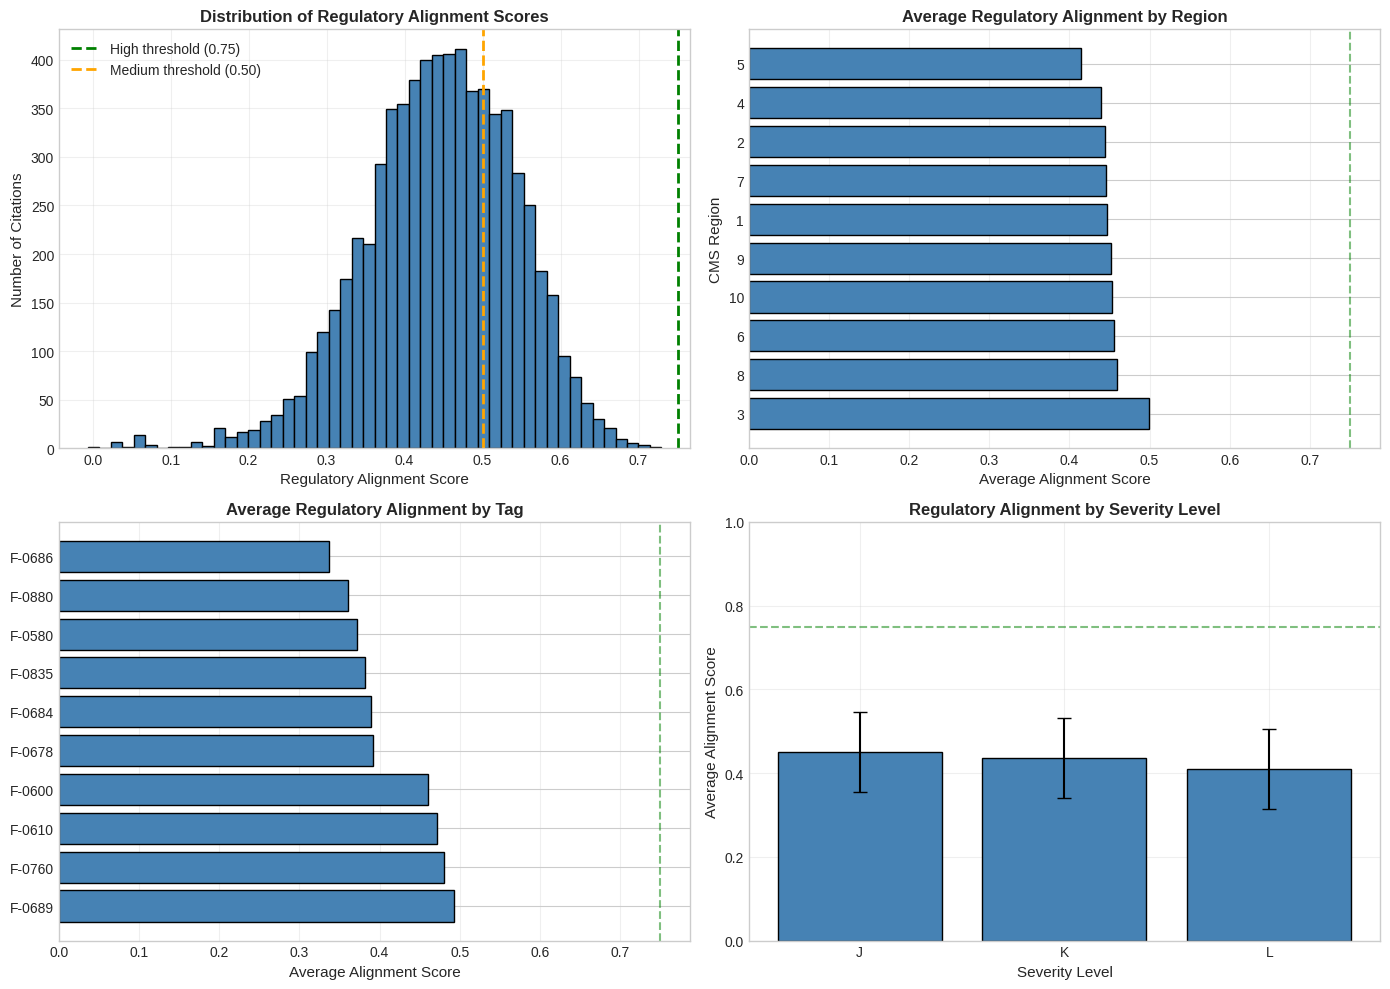

✅ Saved: 01_regulatory_alignment_analysis.png


In [ ]:
# %%
# STEP 3: RQ2 Analysis - Regulatory Alignment
print("="*80)
print("Step 3: RQ2 Analysis - Regulatory Alignment\n")

# Figure 1: Alignment scores distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of alignment scores
axes[0, 0].hist(df_alignment['regulatory_alignment_score'], bins=50, color='steelblue', edgecolor='black')
axes[0, 0].set_xlabel('Regulatory Alignment Score', fontsize=11)
axes[0, 0].set_ylabel('Number of Citations', fontsize=11)
axes[0, 0].set_title('Distribution of Regulatory Alignment Scores', fontsize=12, fontweight='bold')
axes[0, 0].axvline(0.75, color='green', linestyle='--', label='High threshold (0.75)', linewidth=2)
axes[0, 0].axvline(0.50, color='orange', linestyle='--', label='Medium threshold (0.50)', linewidth=2)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Alignment by region
alignment_means = df_alignment_region.sort_values('mean_alignment', ascending=False)
axes[0, 1].barh(alignment_means['region'].astype(str), alignment_means['mean_alignment'],
                 color='steelblue', edgecolor='black')
axes[0, 1].set_xlabel('Average Alignment Score', fontsize=11)
axes[0, 1].set_ylabel('CMS Region', fontsize=11)
axes[0, 1].set_title('Average Regulatory Alignment by Region', fontsize=12, fontweight='bold')
axes[0, 1].axvline(0.75, color='green', linestyle='--', alpha=0.5)
axes[0, 1].grid(axis='x', alpha=0.3)

# Alignment by tag
alignment_by_tag = df_alignment.groupby('Tag')['regulatory_alignment_score'].mean().sort_values(ascending=False)
axes[1, 0].barh(alignment_by_tag.index, alignment_by_tag.values, color='steelblue', edgecolor='black')
axes[1, 0].set_xlabel('Average Alignment Score', fontsize=11)
axes[1, 0].set_title('Average Regulatory Alignment by Tag', fontsize=12, fontweight='bold')
axes[1, 0].axvline(0.75, color='green', linestyle='--', alpha=0.5)
axes[1, 0].grid(axis='x', alpha=0.3)

# Alignment by severity
alignment_by_severity = df_alignment.groupby('severity')['regulatory_alignment_score'].agg(['mean', 'std'])
severity_order = ['J', 'K', 'L']
alignment_by_severity = alignment_by_severity.reindex(severity_order)
axes[1, 1].bar(alignment_by_severity.index, alignment_by_severity['mean'],
               yerr=alignment_by_severity['std'], capsize=5, color='steelblue', edgecolor='black')
axes[1, 1].set_xlabel('Severity Level', fontsize=11)
axes[1, 1].set_ylabel('Average Alignment Score', fontsize=11)
axes[1, 1].set_title('Regulatory Alignment by Severity Level', fontsize=12, fontweight='bold')
axes[1, 1].axhline(0.75, color='green', linestyle='--', alpha=0.5)
axes[1, 1].set_ylim([0, 1])
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '01_regulatory_alignment_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 01_regulatory_alignment_analysis.png")


Step 4: RQ1 Analysis - Regional Consistency



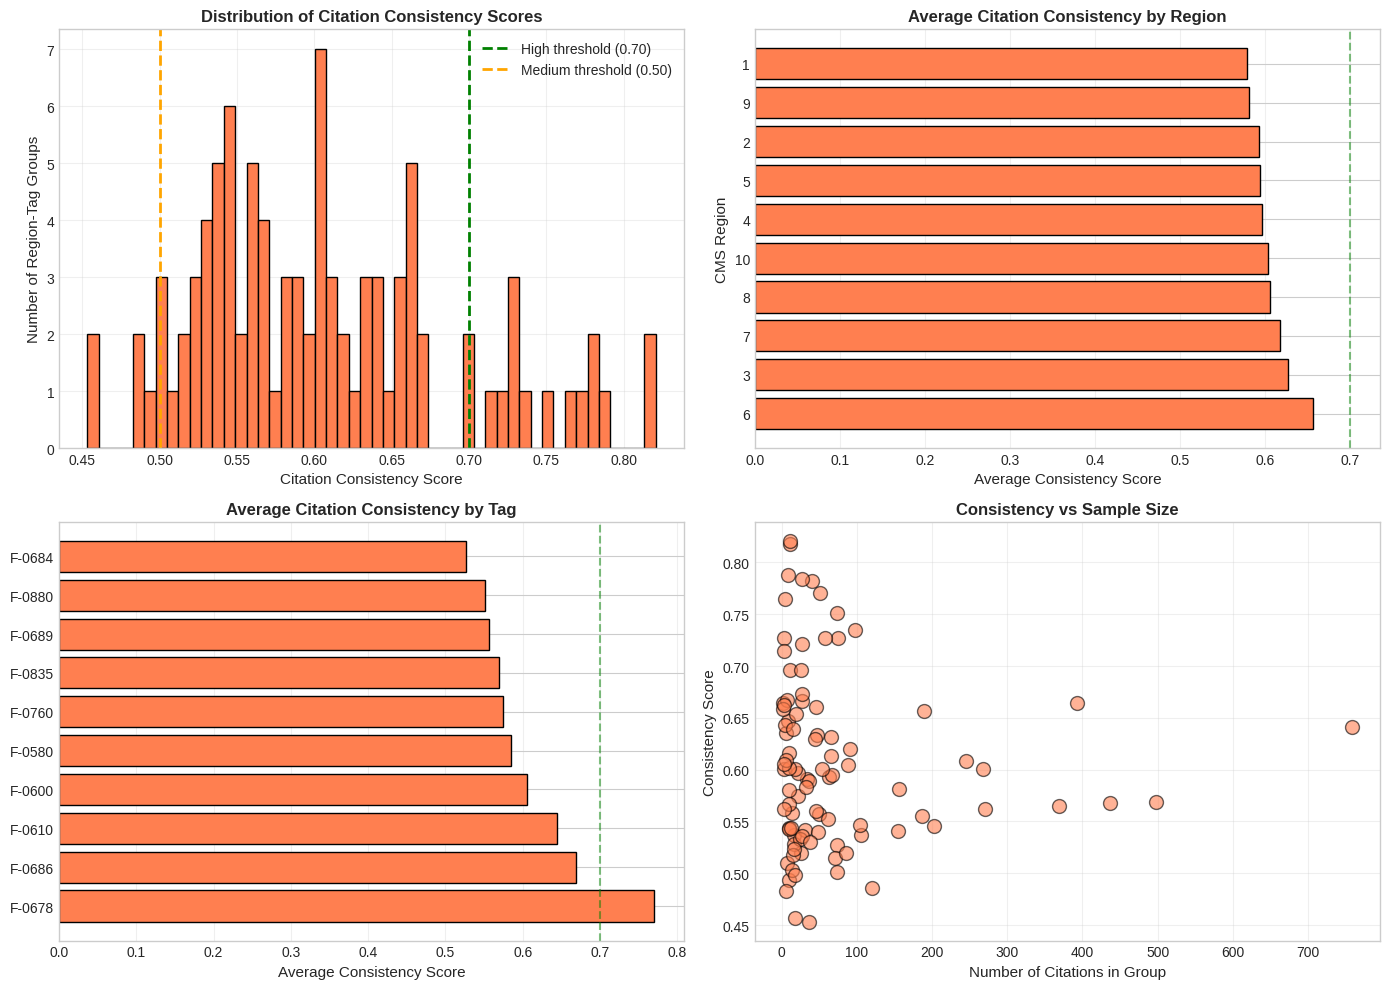

✅ Saved: 02_regional_consistency_analysis.png


In [ ]:
# %%
# STEP 4: RQ1 Analysis - Regional Consistency
print("\n" + "="*80)
print("Step 4: RQ1 Analysis - Regional Consistency\n")

# Figure 2: Consistency scores
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Distribution of consistency scores
axes[0, 0].hist(df_consistency['avg_consistency_score'].dropna(), bins=50, color='coral', edgecolor='black')
axes[0, 0].set_xlabel('Citation Consistency Score', fontsize=11)
axes[0, 0].set_ylabel('Number of Region-Tag Groups', fontsize=11)
axes[0, 0].set_title('Distribution of Citation Consistency Scores', fontsize=12, fontweight='bold')
axes[0, 0].axvline(0.70, color='green', linestyle='--', label='High threshold (0.70)', linewidth=2)
axes[0, 0].axvline(0.50, color='orange', linestyle='--', label='Medium threshold (0.50)', linewidth=2)
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

# Consistency by region
consistency_means = df_consistency_region.sort_values('mean_consistency', ascending=False)
axes[0, 1].barh(consistency_means['region'].astype(str), consistency_means['mean_consistency'],
                 color='coral', edgecolor='black')
axes[0, 1].set_xlabel('Average Consistency Score', fontsize=11)
axes[0, 1].set_ylabel('CMS Region', fontsize=11)
axes[0, 1].set_title('Average Citation Consistency by Region', fontsize=12, fontweight='bold')
axes[0, 1].axvline(0.70, color='green', linestyle='--', alpha=0.5)
axes[0, 1].grid(axis='x', alpha=0.3)

# Consistency by tag
consistency_by_tag = df_consistency.groupby('Tag')['avg_consistency_score'].mean().sort_values(ascending=False)
axes[1, 0].barh(consistency_by_tag.index, consistency_by_tag.values, color='coral', edgecolor='black')
axes[1, 0].set_xlabel('Average Consistency Score', fontsize=11)
axes[1, 0].set_title('Average Citation Consistency by Tag', fontsize=12, fontweight='bold')
axes[1, 0].axvline(0.70, color='green', linestyle='--', alpha=0.5)
axes[1, 0].grid(axis='x', alpha=0.3)

# Consistency vs citation count
scatter_data = df_consistency.dropna(subset=['avg_consistency_score'])
axes[1, 1].scatter(scatter_data['citation_count'], scatter_data['avg_consistency_score'],
                   alpha=0.6, s=100, color='coral', edgecolor='black')
axes[1, 1].set_xlabel('Number of Citations in Group', fontsize=11)
axes[1, 1].set_ylabel('Consistency Score', fontsize=11)
axes[1, 1].set_title('Consistency vs Sample Size', fontsize=12, fontweight='bold')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / '02_regional_consistency_analysis.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 02_regional_consistency_analysis.png")


Step 5: RQ3 Analysis - Regional Variation



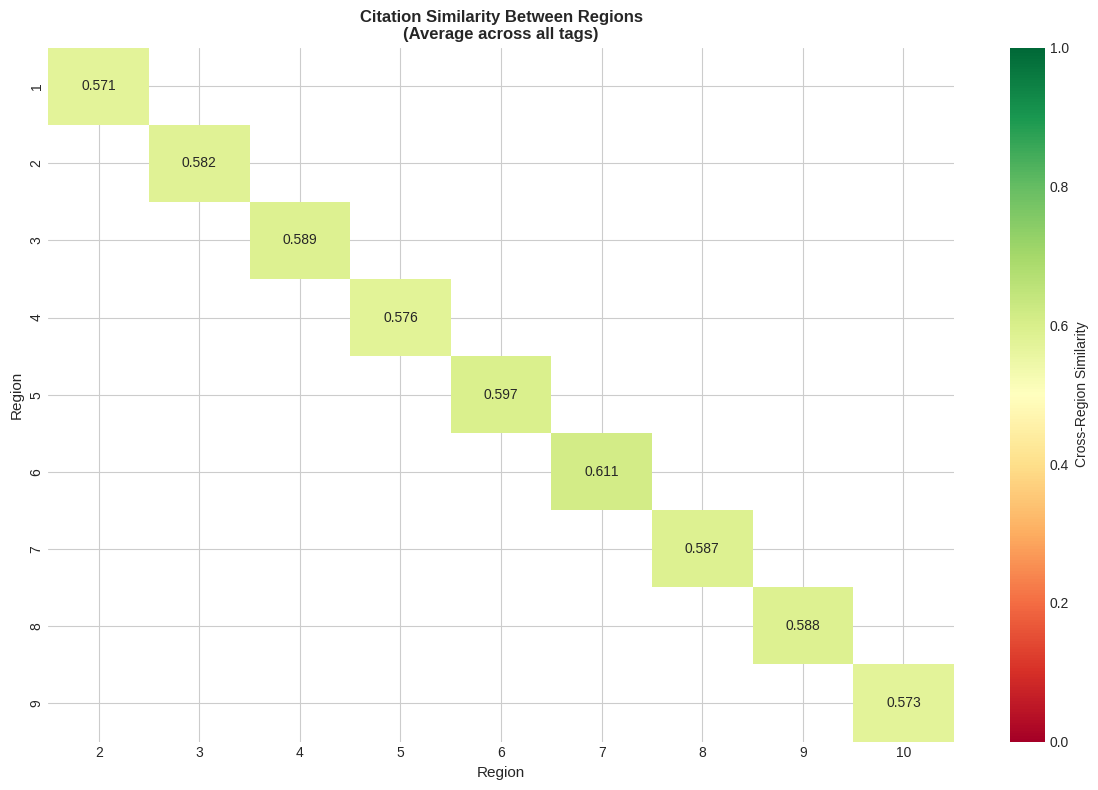

✅ Saved: 03_regional_variation_heatmap.png


In [ ]:
# %%
# STEP 5: RQ3 Analysis - Regional Variation
print("\n" + "="*80)
print("Step 5: RQ3 Analysis - Regional Variation\n")

# Figure 3: Regional variation heatmap
fig, ax = plt.subplots(figsize=(12, 8))

# Create matrix for heatmap - average cross-region similarity by region pair
variation_pivot = df_variation.pivot_table(
    index='region1',
    columns='region2',
    values='cross_region_similarity',
    aggfunc='mean'
)

# Make symmetric
for i in range(len(variation_pivot)):
    for j in range(i+1, len(variation_pivot)):
        variation_pivot.iloc[i, j] = variation_pivot.iloc[j, i]

sns.heatmap(variation_pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0.5,
            cbar_kws={'label': 'Cross-Region Similarity'}, ax=ax, vmin=0, vmax=1)
ax.set_title('Citation Similarity Between Regions\n(Average across all tags)',
             fontsize=12, fontweight='bold')
ax.set_xlabel('Region', fontsize=11)
ax.set_ylabel('Region', fontsize=11)

plt.tight_layout()
plt.savefig(figures_dir / '03_regional_variation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 03_regional_variation_heatmap.png")


Step 6: Comparison Visualizations



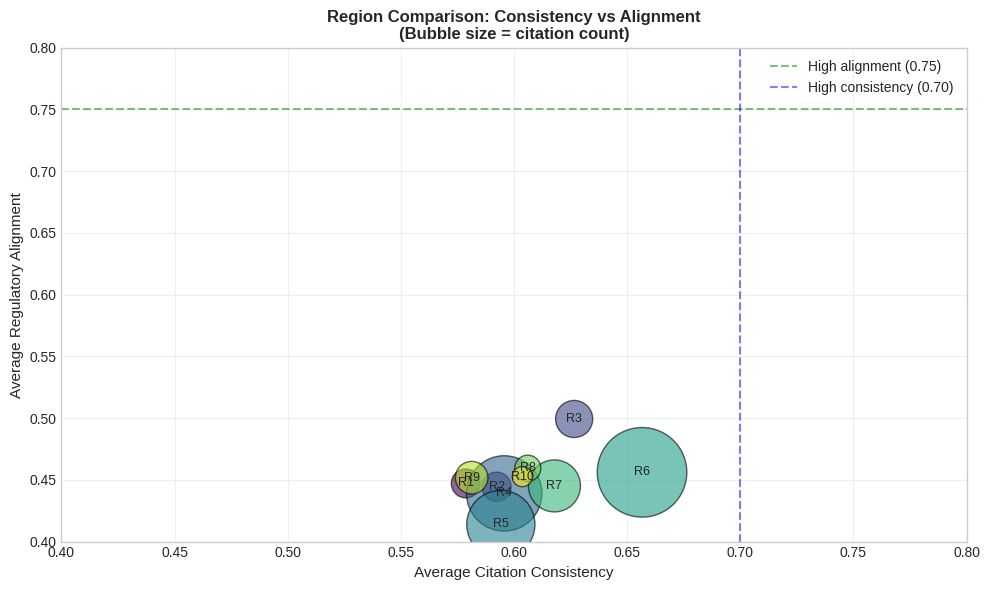

✅ Saved: 04_alignment_vs_consistency_by_region.png


In [ ]:
# %%
# STEP 6: Comparison Visualizations
print("\n" + "="*80)
print("Step 6: Comparison Visualizations\n")

# Figure 4: Alignment vs Consistency by region
fig, ax = plt.subplots(figsize=(10, 6))

merged_regional = df_alignment_region.merge(df_consistency_region, on='region')
scatter = ax.scatter(merged_regional['mean_consistency'], merged_regional['mean_alignment'],
                     s=merged_regional['citation_count']*2, alpha=0.6, c=merged_regional['region'],
                     cmap='viridis', edgecolor='black', linewidth=1)

# Add region labels
for idx, row in merged_regional.iterrows():
    ax.annotate(f"R{int(row['region'])}",
                (row['mean_consistency'], row['mean_alignment']),
                fontsize=9, ha='center', va='center')

ax.set_xlabel('Average Citation Consistency', fontsize=11)
ax.set_ylabel('Average Regulatory Alignment', fontsize=11)
ax.set_title('Region Comparison: Consistency vs Alignment\n(Bubble size = citation count)',
             fontsize=12, fontweight='bold')
ax.axhline(0.75, color='green', linestyle='--', alpha=0.5, label='High alignment (0.75)')
ax.axvline(0.70, color='blue', linestyle='--', alpha=0.5, label='High consistency (0.70)')
ax.grid(alpha=0.3)
ax.legend()
ax.set_xlim([0.4, 0.8])
ax.set_ylim([0.4, 0.8])

plt.tight_layout()
plt.savefig(figures_dir / '04_alignment_vs_consistency_by_region.png', dpi=300, bbox_inches='tight')
plt.show()
print("✅ Saved: 04_alignment_vs_consistency_by_region.png")


In [ ]:
# %%
# STEP 7: Create Summary Report
print("\n" + "="*80)
print("Step 7: Creating Summary Report\n")

summary_report = []

summary_report.append("="*80)
summary_report.append("WEEKS 3-4 ANALYSIS SUMMARY REPORT")
summary_report.append("Consistency Analysis & Regulatory Alignment")
summary_report.append("="*80)
summary_report.append("")

summary_report.append("RESEARCH QUESTION 1: REGIONAL CONSISTENCY")
summary_report.append("-" * 80)
summary_report.append(f"Question: How consistently are IJ citations written within each region?")
summary_report.append("")
summary_report.append("Key Findings:")
top_consistent = df_consistency_region.nlargest(3, 'mean_consistency')
for idx, row in top_consistent.iterrows():
    summary_report.append(f"  • Region {int(row['region'])}: {row['mean_consistency']:.4f} (±{row['std_consistency']:.4f})")

summary_report.append("")
summary_report.append(f"Overall Average Consistency: {df_consistency['avg_consistency_score'].mean():.4f}")
summary_report.append("")

summary_report.append("RESEARCH QUESTION 2: REGULATORY ALIGNMENT")
summary_report.append("-" * 80)
summary_report.append(f"Question: How closely do citations align with CMS Appendix PP language?")
summary_report.append("")
summary_report.append("Key Findings:")
top_aligned = df_alignment_region.nlargest(3, 'mean_alignment')
for idx, row in top_aligned.iterrows():
    summary_report.append(f"  • Region {int(row['region'])}: {row['mean_alignment']:.4f} (±{row['std_alignment']:.4f})")

summary_report.append("")
summary_report.append(f"Overall Average Alignment: {df_alignment['regulatory_alignment_score'].mean():.4f}")
summary_report.append("")

# Alignment by tag
summary_report.append("Tags with Best Alignment:")
tag_alignment = df_alignment.groupby('Tag')['regulatory_alignment_score'].mean().nlargest(3)
for tag, score in tag_alignment.items():
    summary_report.append(f"  • {tag}: {score:.4f}")

summary_report.append("")

summary_report.append("RESEARCH QUESTION 3: SYSTEMATIC REGIONAL DIFFERENCES")
summary_report.append("-" * 80)
summary_report.append(f"Question: Do regions differ systematically in citation practices?")
summary_report.append("")
summary_report.append("Statistical Test Results (ANOVA):")
summary_report.append(f"  • Alignment Scores: F={anova_results[anova_results['test']=='Alignment Scores']['f_statistic'].values[0]:.4f}, "
                     f"p={anova_results[anova_results['test']=='Alignment Scores']['p_value'].values[0]:.6f}")

alignment_sig = anova_results[anova_results['test']=='Alignment Scores']['significant'].values[0]
if alignment_sig:
    summary_report.append(f"    → SIGNIFICANT ✅ (Regional differences are real, not random)")
else:
    summary_report.append(f"    → NOT SIGNIFICANT (Differences could be due to chance)")

summary_report.append("")
summary_report.append(f"  • Consistency Scores: F={anova_results[anova_results['test']=='Consistency Scores']['f_statistic'].values[0]:.4f}, "
                     f"p={anova_results[anova_results['test']=='Consistency Scores']['p_value'].values[0]:.6f}")

consistency_sig = anova_results[anova_results['test']=='Consistency Scores']['significant'].values[0]
if consistency_sig:
    summary_report.append(f"    → SIGNIFICANT ✅ (Regional differences are real, not random)")
else:
    summary_report.append(f"    → NOT SIGNIFICANT (Differences could be due to chance)")

summary_report.append("")

summary_report.append("KEY INSIGHTS")
summary_report.append("-" * 80)
summary_report.append("1. Distribution of Alignment Scores:")
high_alignment = (df_alignment['regulatory_alignment_score'] >= 0.75).sum()
med_alignment = ((df_alignment['regulatory_alignment_score'] >= 0.50) &
                 (df_alignment['regulatory_alignment_score'] < 0.75)).sum()
low_alignment = (df_alignment['regulatory_alignment_score'] < 0.50).sum()

summary_report.append(f"   • High alignment (≥0.75): {high_alignment:,} citations ({100*high_alignment/len(df_alignment):.1f}%)")
summary_report.append(f"   • Medium alignment (0.50-0.75): {med_alignment:,} citations ({100*med_alignment/len(df_alignment):.1f}%)")
summary_report.append(f"   • Low alignment (<0.50): {low_alignment:,} citations ({100*low_alignment/len(df_alignment):.1f}%)")

summary_report.append("")
summary_report.append("2. Regional Patterns:")
summary_report.append(f"   • Most consistent region: Region {int(consistency_means.iloc[0]['region'])} "
                     f"({consistency_means.iloc[0]['mean_consistency']:.4f})")
summary_report.append(f"   • Best aligned region: Region {int(alignment_means.iloc[0]['region'])} "
                     f"({alignment_means.iloc[0]['mean_alignment']:.4f})")

summary_report.append("")
summary_report.append("3. AI Approach Effectiveness:")
summary_report.append("   ✅ Sentence Transformers + Cosine Similarity successfully:")
summary_report.append("      - Quantified citation consistency within regions")
summary_report.append("      - Measured alignment with regulatory standards")
summary_report.append("      - Identified systematic regional differences")
summary_report.append("      - Provided statistical validation (ANOVA)")

summary_report.append("")
summary_report.append("NEXT STEPS")
summary_report.append("-" * 80)
summary_report.append("Weeks 5-6: Regulatory Alignment Deep-Dive")
summary_report.append("  • Identify specific areas where citations deviate from regulations")
summary_report.append("  • Classify deviation types (expansion/reduction/reinterpretation)")
summary_report.append("  • Create actionable recommendations for AHCA")

summary_report.append("")
summary_report.append("Weeks 7-8: Compare 3 AI Approaches")
summary_report.append("  • Test fine-tuned domain-specific models")
summary_report.append("  • Test LLM-based approaches (GPT-4/Claude)")
summary_report.append("  • Compare quality, speed, cost")
summary_report.append("  • Recommend best approach for AHCA")

summary_report.append("")
summary_report.append("="*80)

# Save report
report_path = data_dir / 'week3-4_analysis_summary_report.txt'
with open(report_path, 'w') as f:
    f.write('\n'.join(summary_report))

print(f"✅ Saved summary report: week3-4_analysis_summary_report.txt\n")

# Print report
print('\n'.join(summary_report))


Step 7: Creating Summary Report

✅ Saved summary report: week3-4_analysis_summary_report.txt

WEEKS 3-4 ANALYSIS SUMMARY REPORT
Consistency Analysis & Regulatory Alignment

RESEARCH QUESTION 1: REGIONAL CONSISTENCY
--------------------------------------------------------------------------------
Question: How consistently are IJ citations written within each region?

Key Findings:
  • Region 6: 0.6566 (±0.0663)
  • Region 3: 0.6266 (±0.0677)
  • Region 7: 0.6179 (±0.0730)

Overall Average Consistency: 0.6057

RESEARCH QUESTION 2: REGULATORY ALIGNMENT
--------------------------------------------------------------------------------
Question: How closely do citations align with CMS Appendix PP language?

Key Findings:
  • Region 3: 0.4993 (±0.0998)
  • Region 8: 0.4594 (±0.0957)
  • Region 6: 0.4561 (±0.0912)

Overall Average Alignment: 0.4453

Tags with Best Alignment:
  • F-0689: 0.4934
  • F-0760: 0.4809
  • F-0610: 0.4722

RESEARCH QUESTION 3: SYSTEMATIC REGIONAL DIFFERENCES
---------

In [ ]:
# %%
# STEP 8: Final Summary
print("\n" + "="*80)
print("ANALYSIS COMPLETE")
print("="*80 + "\n")

print("Outputs Generated:")
print("├─ Visualizations:")
print("│  ├─ 01_regulatory_alignment_analysis.png")
print("│  ├─ 02_regional_consistency_analysis.png")
print("│  ├─ 03_regional_variation_heatmap.png")
print("│  └─ 04_alignment_vs_consistency_by_region.png")
print("│")
print("├─ Data Files:")
print("│  ├─ similarity_scores_regulatory_alignment.csv")
print("│  ├─ consistency_scores_within_region.csv")
print("│  ├─ variation_scores_between_regions.csv")
print("│  ├─ alignment_by_region.csv")
print("│  ├─ consistency_by_region.csv")
print("│  └─ anova_results_by_region.csv")
print("│")
print("└─ Reports:")
print("   └─ week3-4_analysis_summary_report.txt")

print(f"\nAll outputs saved to: {data_dir}")

print("\nResearch Questions Answered:")
print("├─ RQ1: Regional Consistency ✅")
print("├─ RQ2: Regulatory Alignment ✅")
print("├─ RQ3: Systematic Regional Differences ✅")
print("└─ Statistical Validation (ANOVA) ✅")

print("\n🎉 WEEKS 3-4 ANALYSIS COMPLETE!")
print("\nYou have proven that AI (Sentence Transformers + Cosine Similarity) can:")
print("  ✓ Measure citation consistency across regions")
print("  ✓ Assess alignment with regulatory language")
print("  ✓ Identify systematic regional patterns")
print("  ✓ Provide statistical validation")

print("\nReady for Weeks 5-6: Regulatory Alignment Deep-Dive")
print("="*80)


ANALYSIS COMPLETE

Outputs Generated:
├─ Visualizations:
│  ├─ 01_regulatory_alignment_analysis.png
│  ├─ 02_regional_consistency_analysis.png
│  ├─ 03_regional_variation_heatmap.png
│  └─ 04_alignment_vs_consistency_by_region.png
│
├─ Data Files:
│  ├─ similarity_scores_regulatory_alignment.csv
│  ├─ consistency_scores_within_region.csv
│  ├─ variation_scores_between_regions.csv
│  ├─ alignment_by_region.csv
│  ├─ consistency_by_region.csv
│  └─ anova_results_by_region.csv
│
└─ Reports:
   └─ week3-4_analysis_summary_report.txt

All outputs saved to: /content/gdrive/My Drive/AHCA Project/filtered_data_sets

Research Questions Answered:
├─ RQ1: Regional Consistency ✅
├─ RQ2: Regulatory Alignment ✅
├─ RQ3: Systematic Regional Differences ✅
└─ Statistical Validation (ANOVA) ✅

🎉 WEEKS 3-4 ANALYSIS COMPLETE!

You have proven that AI (Sentence Transformers + Cosine Similarity) can:
  ✓ Measure citation consistency across regions
  ✓ Assess alignment with regulatory language
  ✓ Identify s